# Datathon 2026 — EDA Notebook

**Mục tiêu:** thực hiện phân tích thăm dò dữ liệu cho bộ dữ liệu e-commerce thời trang.

Notebook này tập trung vào:

1. Đọc và kiểm tra toàn bộ file CSV.
2. Kiểm tra chất lượng dữ liệu: missing values, duplicates, kiểu dữ liệu, outliers cơ bản.
3. Phân tích từng nhóm bảng: Master, Transaction, Analytical, Operational.
4. Join các bảng chính để tạo insight kinh doanh.
5. Tạo biểu đồ phục vụ report phần EDA.
6. Đề xuất các hướng phân tích Prescriptive để ăn điểm rubric.

> Lưu ý: notebook này được thiết kế để chạy an toàn. Nếu thiếu file, nó sẽ báo rõ thay vì crash vô nghĩa.

## 0 — Cài đặt & cấu hình

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =========================
# CONFIG
# =========================
DATA_DIR = Path(".")   # đổi thành Path(".") nếu CSV nằm cùng thư mục notebook
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("DATA_DIR:", DATA_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

DATA_DIR: D:\code\.vscode\DATATHON
OUTPUT_DIR: D:\code\.vscode\DATATHON\outputs


## 1 — Khai báo schema và đọc dữ liệu

In [2]:
FILES = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "sample_submission": "sample_submission.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}

DATE_COLS = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "sample_submission": ["Date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}

def load_csv(name, filename):
    path = DATA_DIR / filename
    if not path.exists():
        print(f"[MISSING] {filename}")
        return None

    parse_dates = DATE_COLS.get(name, [])
    try:
        df = pd.read_csv(path, parse_dates=parse_dates)
        print(f"[OK] {filename}: {df.shape[0]:,} rows x {df.shape[1]:,} cols")
        return df
    except Exception as e:
        print(f"[ERROR] Cannot load {filename}: {e}")
        return None

dfs = {name: load_csv(name, filename) for name, filename in FILES.items()}

available = [k for k, v in dfs.items() if v is not None]
missing = [FILES[k] for k, v in dfs.items() if v is None]

print("\nAvailable tables:", available)
print("Missing files:", missing)

[OK] products.csv: 2,412 rows x 8 cols
[OK] customers.csv: 121,930 rows x 7 cols
[OK] promotions.csv: 50 rows x 10 cols
[OK] geography.csv: 39,948 rows x 4 cols
[OK] orders.csv: 646,945 rows x 8 cols
[OK] order_items.csv: 714,669 rows x 7 cols
[OK] payments.csv: 646,945 rows x 4 cols
[OK] shipments.csv: 566,067 rows x 4 cols
[OK] returns.csv: 39,939 rows x 7 cols
[OK] reviews.csv: 113,551 rows x 7 cols
[OK] sales.csv: 3,833 rows x 3 cols
[OK] sample_submission.csv: 548 rows x 3 cols
[OK] inventory.csv: 60,247 rows x 17 cols
[OK] web_traffic.csv: 3,652 rows x 7 cols

Available tables: ['products', 'customers', 'promotions', 'geography', 'orders', 'order_items', 'payments', 'shipments', 'returns', 'reviews', 'sales', 'sample_submission', 'inventory', 'web_traffic']
Missing files: []


## 2 — Tổng quan cấu trúc dữ liệu

In [3]:
def table_overview(dfs):
    rows = []
    for name, df in dfs.items():
        if df is None:
            rows.append({
                "table": name,
                "rows": None,
                "cols": None,
                "missing_cells": None,
                "duplicate_rows": None,
                "memory_mb": None,
            })
            continue

        rows.append({
            "table": name,
            "rows": df.shape[0],
            "cols": df.shape[1],
            "missing_cells": int(df.isna().sum().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
            "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        })

    return pd.DataFrame(rows).sort_values(["rows"], ascending=False, na_position="last")

overview = table_overview(dfs)
overview

,table,rows,cols,missing_cells,duplicate_rows,memory_mb
5,order_items,714669,7,1152816,0,80.11
4,orders,646945,8,0,0,182.52
6,payments,646945,4,0,0,55.50
7,shipments,566067,4,0,0,17.28
1,customers,121930,7,0,0,32.77
9,reviews,113551,7,0,0,19.49
12,inventory,60247,17,0,0,18.14
3,geography,39948,4,0,0,7.78
8,returns,39939,7,0,0,6.68
10,sales,3833,3,0,0,0.09


In [4]:
# Lưu overview để đưa vào report nếu cần
overview.to_csv(OUTPUT_DIR / "table_overview.csv", index=False)
print("Saved:", OUTPUT_DIR / "table_overview.csv")

Saved: outputs\table_overview.csv


## 3 — Kiểm tra missing values, dtype, duplicate

In [5]:
def missing_report(df, table_name):
    if df is None:
        return pd.DataFrame()

    report = pd.DataFrame({
        "table": table_name,
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": df.nunique(dropna=True).values,
    })

    return report.sort_values(["missing_pct", "n_unique"], ascending=[False, True])

missing_reports = []
for name, df in dfs.items():
    if df is not None:
        missing_reports.append(missing_report(df, name))

missing_all = pd.concat(missing_reports, ignore_index=True) if missing_reports else pd.DataFrame()
missing_all

,table,column,dtype,missing_count,missing_pct,n_unique
0,products,category,str,0,0.00,4
1,products,size,str,0,0.00,4
2,products,segment,str,0,0.00,8
3,products,color,str,0,0.00,10
4,products,price,float64,0,0.00,1990
5,products,product_name,str,0,0.00,2172
6,products,cogs,float64,0,0.00,2381
7,products,product_id,int64,0,0.00,2412
8,customers,gender,str,0,0.00,3
9,customers,age_group,str,0,0.00,5


In [ ]:
missing_all.to_csv(OUTPUT_DIR / "missing_report.csv", index=False)
print("Saved:", OUTPUT_DIR / "missing_report.csv")

## 4 — Helper functions cho visualization

In [6]:
def savefig(name):
    path = OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)
    plt.show()

def plot_bar(series, title, xlabel="", ylabel="", top_n=20, filename=None):
    s = series.dropna()
    if top_n is not None:
        s = s.head(top_n)

    plt.figure(figsize=(10, max(4, len(s) * 0.35)))
    s.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if filename:
        savefig(filename)
    else:
        plt.tight_layout()
        plt.show()

def plot_line(df, x, y, title, xlabel="", ylabel="", filename=None):
    plt.figure(figsize=(14, 5))
    plt.plot(df[x], df[y], linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if filename:
        savefig(filename)
    else:
        plt.tight_layout()
        plt.show()

def numeric_summary(df):
    if df is None:
        return pd.DataFrame()
    return df.select_dtypes(include=[np.number]).describe().T

## 5 — Master Tables: Products, Customers, Promotions, Geography

### 5.1 Products — danh mục, segment, margin

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.65","9,704.84"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.08","5,393.87"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.63","11,371.92"
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,"15,753.72","8,573.17"
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,"15,766.33","14,063.57"


,count,mean,std,min,25%,50%,75%,max
product_id,"2,412.00","1,206.50",696.43,1.00,603.75,"1,206.50","1,809.25","2,412.00"
price,"2,412.00","4,928.22","4,776.74",9.06,59.44,"4,399.60","7,720.51","40,950.00"
cogs,"2,412.00","3,868.35","3,878.58",5.18,35.07,"3,184.93","5,864.92","38,902.50"


Invalid cogs >= price: 0


,price,cogs,gross_margin,gross_margin_rate
count,"2,412.00","2,412.00","2,412.00","2,412.00"
mean,"4,928.22","3,868.35","1,059.87",0.27
std,"4,776.74","3,878.58","1,422.07",0.15
min,9.06,5.18,3.87,0.05
25%,59.44,35.07,23.55,0.10
50%,"4,399.60","3,184.93",490.87,0.31
75%,"7,720.51","5,864.92","1,553.39",0.40
max,"40,950.00","38,902.50","13,118.39",0.50


Saved: outputs\product_count_by_category.png


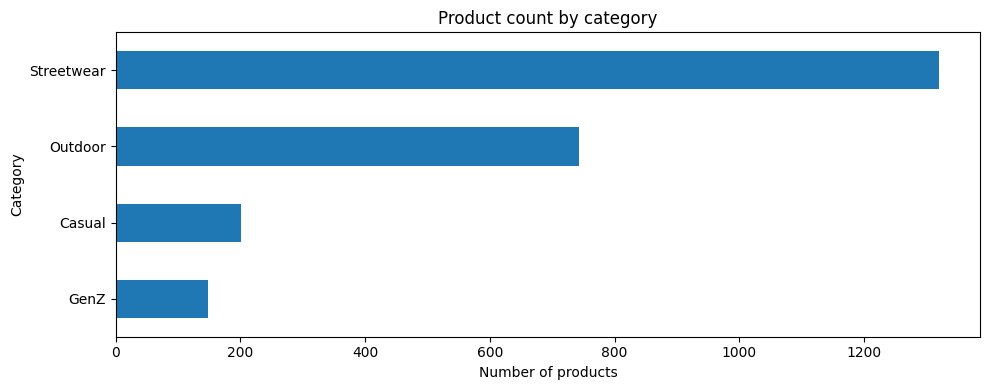

Saved: outputs\product_count_by_segment.png


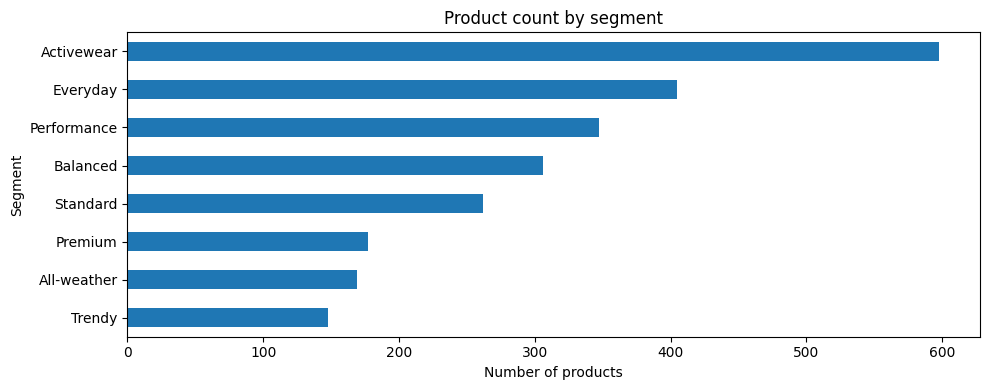

Saved: outputs\avg_margin_by_segment.png


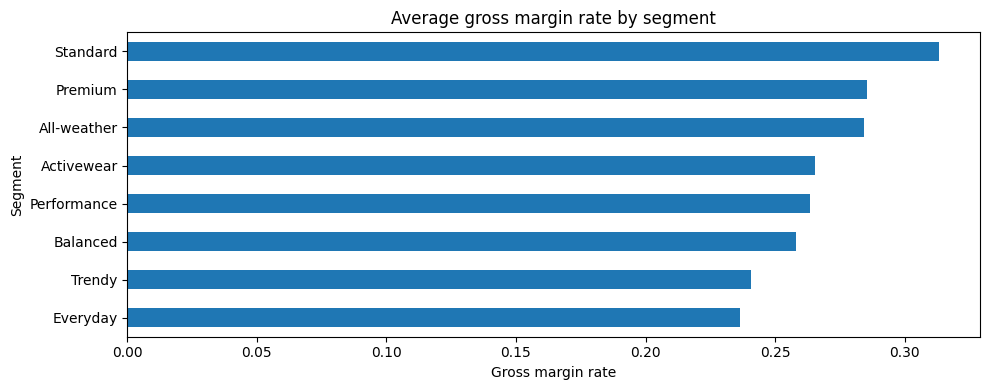

In [7]:
products = dfs.get("products")

if products is not None:
    display(products.head())
    display(numeric_summary(products))

    if {"price", "cogs"}.issubset(products.columns):
        products = products.copy()
        products["gross_margin"] = products["price"] - products["cogs"]
        products["gross_margin_rate"] = products["gross_margin"] / products["price"]

        print("Invalid cogs >= price:", (products["cogs"] >= products["price"]).sum())
        display(products[["price", "cogs", "gross_margin", "gross_margin_rate"]].describe())

    if "category" in products.columns:
        plot_bar(
            products["category"].value_counts(),
            "Product count by category",
            xlabel="Number of products",
            ylabel="Category",
            filename="product_count_by_category.png"
        )

    if "segment" in products.columns:
        plot_bar(
            products["segment"].value_counts(),
            "Product count by segment",
            xlabel="Number of products",
            ylabel="Segment",
            filename="product_count_by_segment.png"
        )

    if {"segment", "gross_margin_rate"}.issubset(products.columns):
        margin_by_segment = products.groupby("segment")["gross_margin_rate"].mean().sort_values(ascending=False)
        plot_bar(
            margin_by_segment,
            "Average gross margin rate by segment",
            xlabel="Gross margin rate",
            ylabel="Segment",
            filename="avg_margin_by_segment.png"
        )
else:
    print("products.csv chưa có.")

### 5.2 Customers — acquisition, age, gender, signup trend

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


,table,column,dtype,missing_count,missing_pct,n_unique
4,customers,gender,str,0,0.00,3
5,customers,age_group,str,0,0.00,5
6,customers,acquisition_channel,str,0,0.00,6
2,customers,city,str,0,0.00,42
3,customers,signup_date,datetime64[us],0,0.00,3941
1,customers,zip,int64,0,0.00,31491
0,customers,customer_id,int64,0,0.00,121930


Saved: outputs\customers_by_gender.png


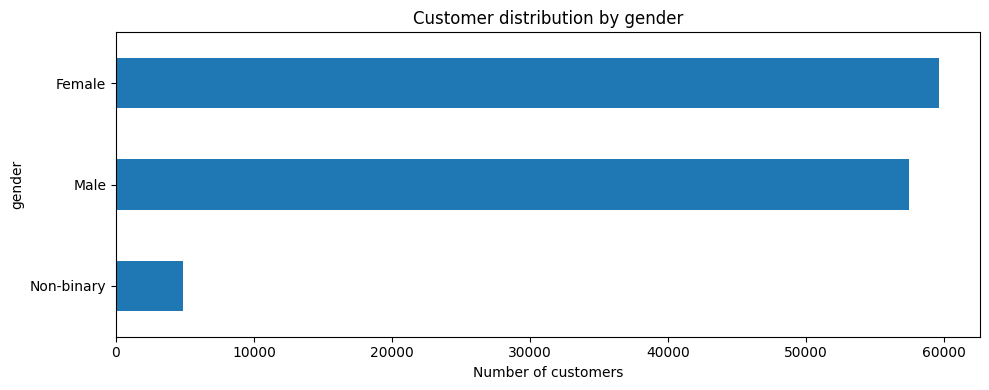

Saved: outputs\customers_by_age_group.png


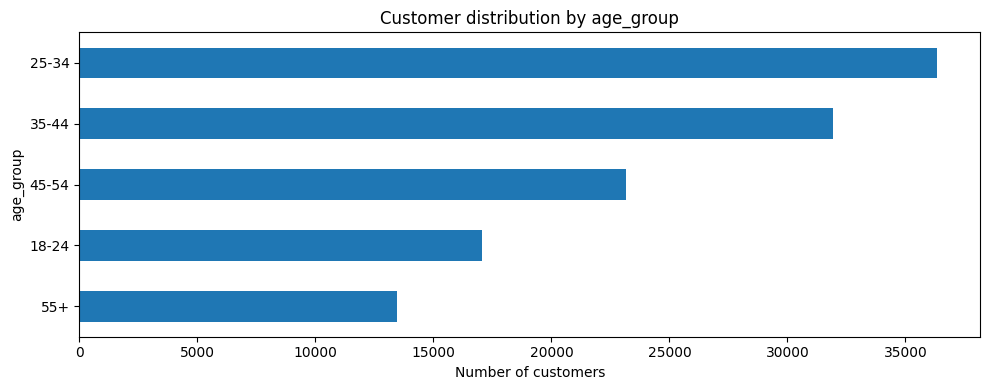

Saved: outputs\customers_by_acquisition_channel.png


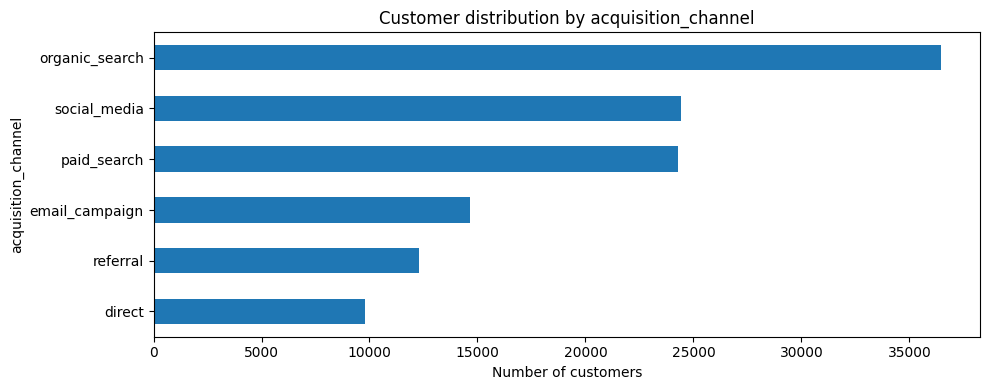

Saved: outputs\customers_by_city.png


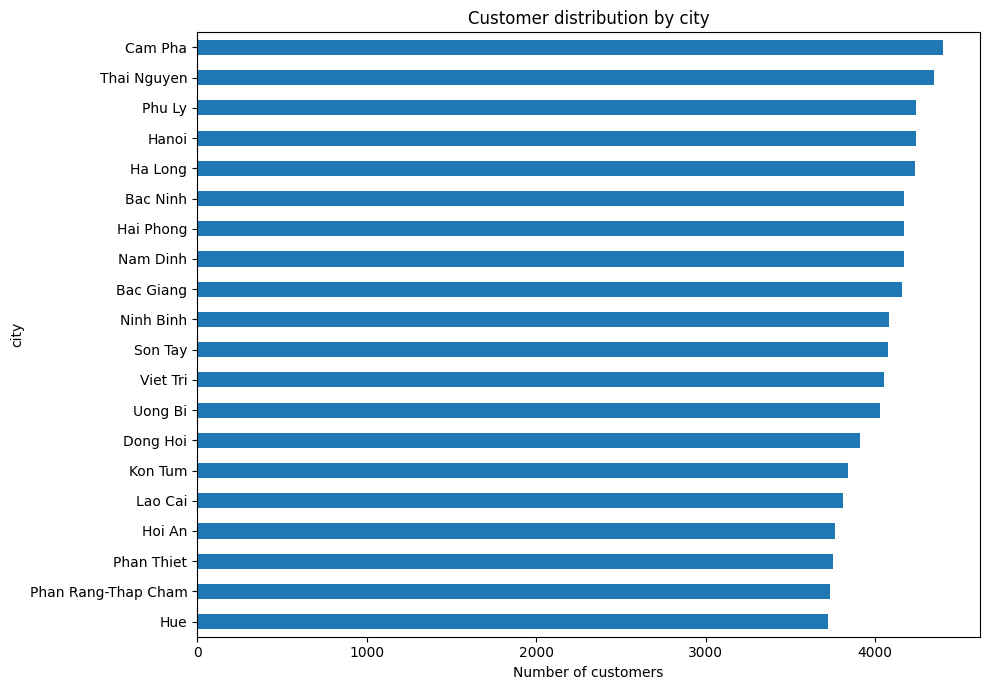

Saved: outputs\monthly_customer_signups.png


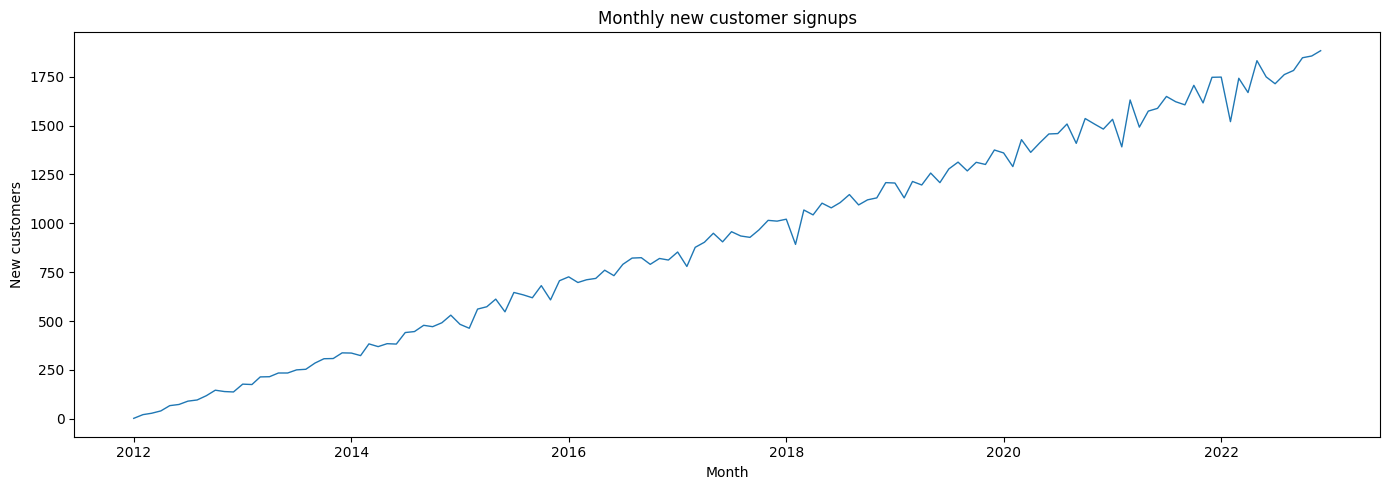

In [8]:
customers = dfs.get("customers")

if customers is not None:
    display(customers.head())
    display(missing_report(customers, "customers"))

    for col in ["gender", "age_group", "acquisition_channel", "city"]:
        if col in customers.columns:
            plot_bar(
                customers[col].value_counts(),
                f"Customer distribution by {col}",
                xlabel="Number of customers",
                ylabel=col,
                top_n=20,
                filename=f"customers_by_{col}.png"
            )

    if "signup_date" in customers.columns:
        signup_monthly = (
            customers
            .dropna(subset=["signup_date"])
            .assign(signup_month=lambda x: x["signup_date"].dt.to_period("M").dt.to_timestamp())
            .groupby("signup_month")
            .size()
            .reset_index(name="new_customers")
        )

        plot_line(
            signup_monthly,
            "signup_month",
            "new_customers",
            "Monthly new customer signups",
            xlabel="Month",
            ylabel="New customers",
            filename="monthly_customer_signups.png"
        )
else:
    print("customers.csv chưa có.")

### 5.3 Promotions — loại promo, thời gian, điều kiện áp dụng

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.00,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.00,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.00,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.00,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.00,2013-07-30,2013-09-02,Streetwear,online,0,150000


,table,column,dtype,missing_count,missing_pct,n_unique
6,promotions,applicable_category,str,40,80.00,2
2,promotions,promo_type,str,0,0.00,2
8,promotions,stackable_flag,int64,0,0.00,2
7,promotions,promo_channel,str,0,0.00,5
9,promotions,min_order_value,int64,0,0.00,5
3,promotions,discount_value,float64,0,0.00,6
0,promotions,promo_id,str,0,0.00,50
1,promotions,promo_name,str,0,0.00,50
4,promotions,start_date,datetime64[us],0,0.00,50
5,promotions,end_date,datetime64[us],0,0.00,50


Saved: outputs\promotions_by_promo_type.png


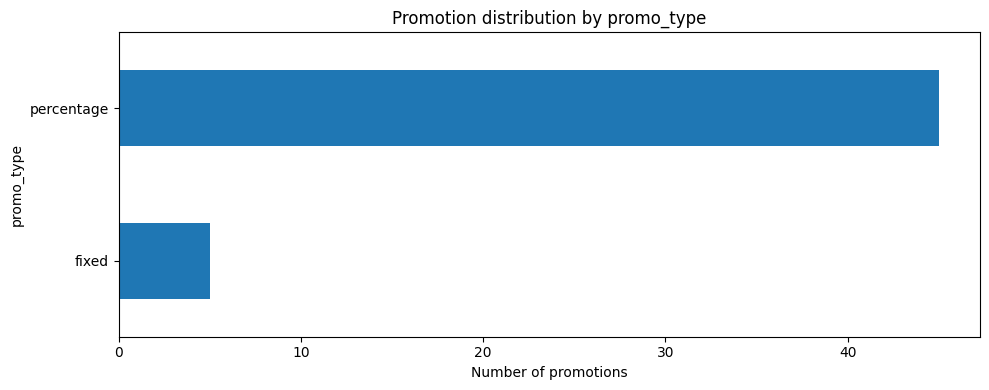

Saved: outputs\promotions_by_applicable_category.png


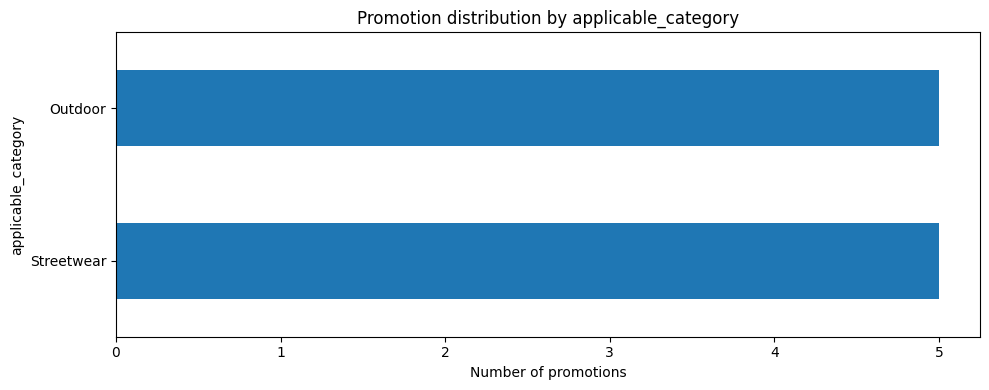

Saved: outputs\promotions_by_promo_channel.png


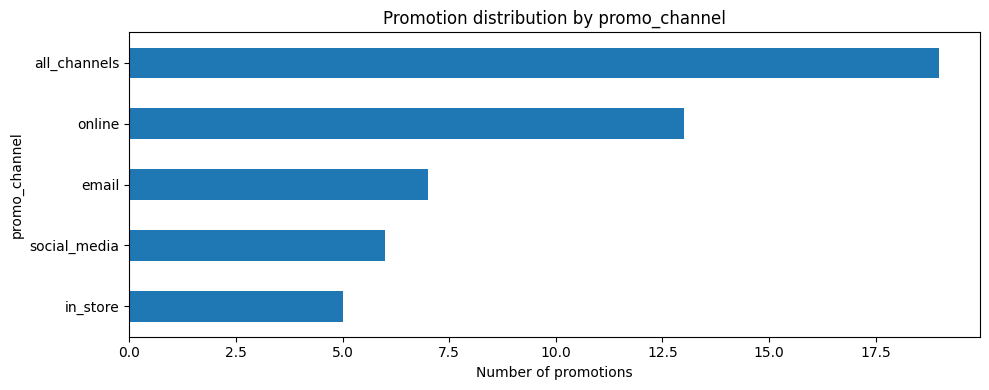

Saved: outputs\promotions_by_stackable_flag.png


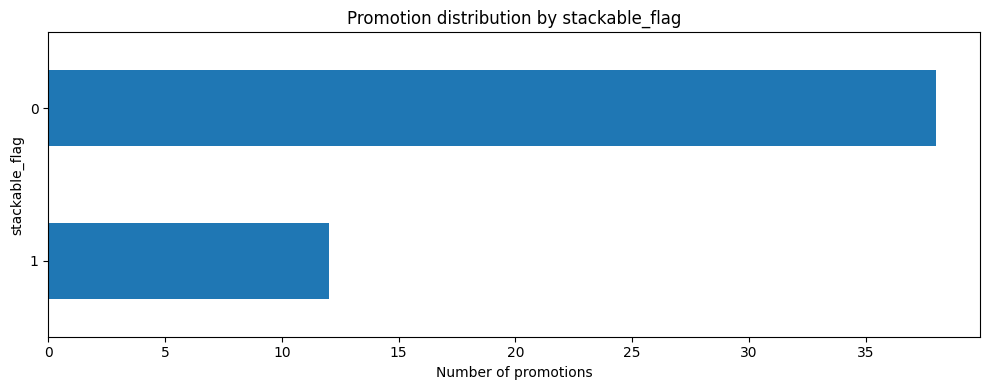

count   50.00
mean    34.54
std      5.81
min     30.00
25%     31.00
50%     31.50
75%     35.00
max     46.00
Name: duration_days, dtype: float64

In [9]:
promotions = dfs.get("promotions")

if promotions is not None:
    display(promotions.head())
    display(missing_report(promotions, "promotions"))

    for col in ["promo_type", "applicable_category", "promo_channel", "stackable_flag"]:
        if col in promotions.columns:
            plot_bar(
                promotions[col].value_counts(),
                f"Promotion distribution by {col}",
                xlabel="Number of promotions",
                ylabel=col,
                top_n=20,
                filename=f"promotions_by_{col}.png"
            )

    if {"start_date", "end_date"}.issubset(promotions.columns):
        promotions = promotions.copy()
        promotions["duration_days"] = (promotions["end_date"] - promotions["start_date"]).dt.days + 1
        display(promotions["duration_days"].describe())
else:
    print("promotions.csv chưa có.")

## 6 — Transaction Tables: Orders, Items, Payments, Shipments, Returns, Reviews

### 6.1 Orders — volume, status, source, device, payment method

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


,table,column,dtype,missing_count,missing_pct,n_unique
6,orders,device_type,str,0,0.00,3
5,orders,payment_method,str,0,0.00,5
4,orders,order_status,str,0,0.00,6
7,orders,order_source,str,0,0.00,6
1,orders,order_date,datetime64[us],0,0.00,3833
3,orders,zip,int64,0,0.00,29932
2,orders,customer_id,int64,0,0.00,90246
0,orders,order_id,int64,0,0.00,646945


Saved: outputs\orders_by_order_status.png


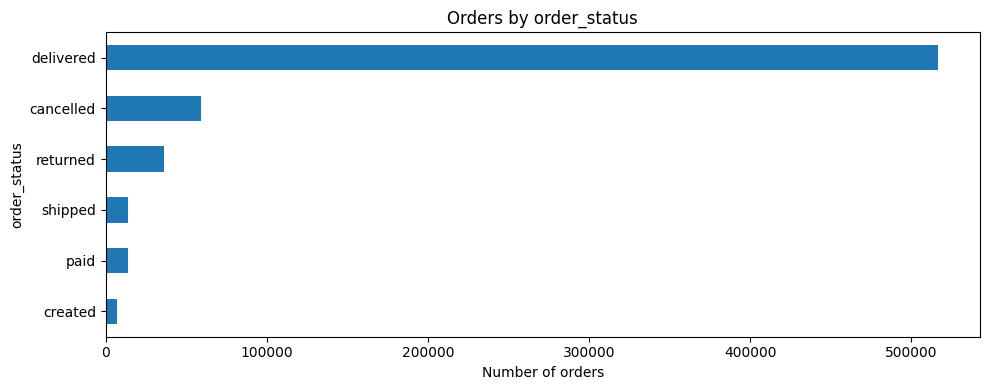

Saved: outputs\orders_by_payment_method.png


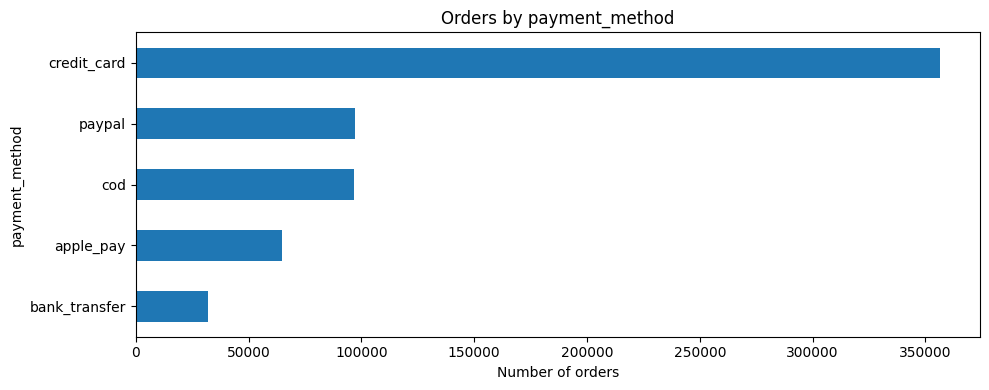

Saved: outputs\orders_by_device_type.png


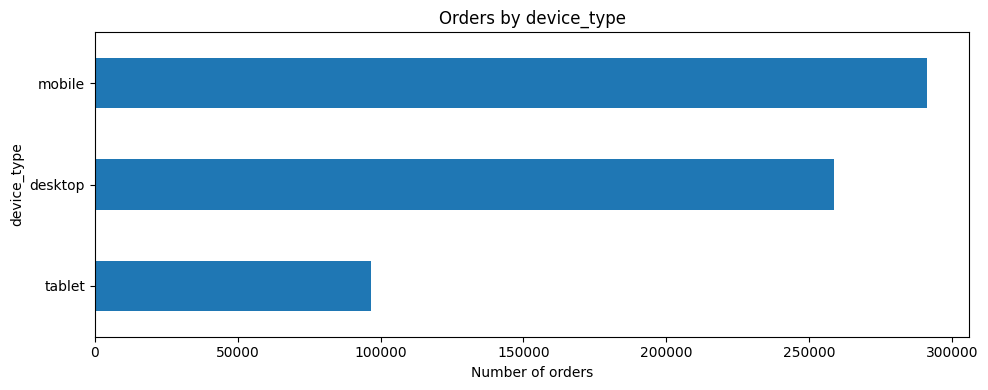

Saved: outputs\orders_by_order_source.png


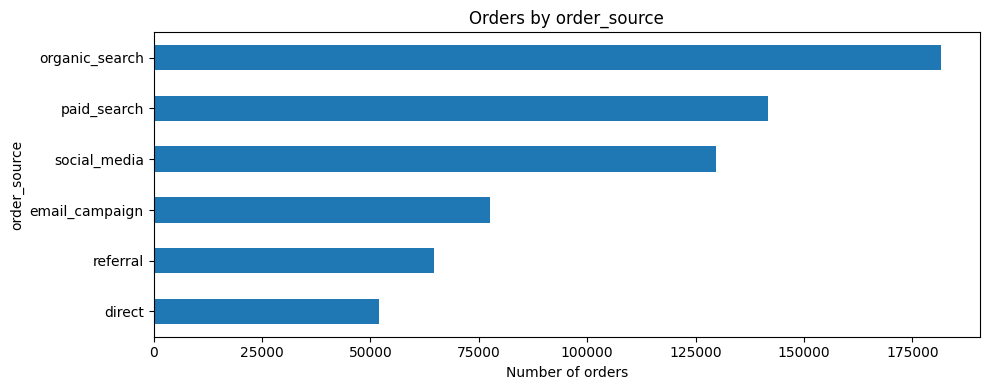

Saved: outputs\daily_order_volume.png


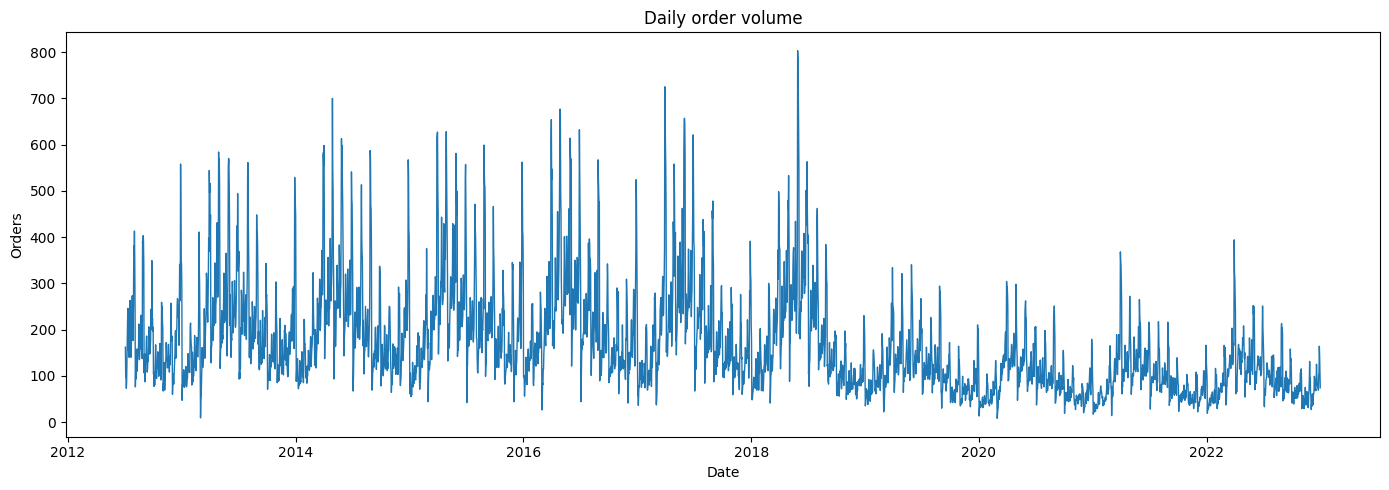

In [10]:
orders = dfs.get("orders")

if orders is not None:
    display(orders.head())
    display(missing_report(orders, "orders"))

    for col in ["order_status", "payment_method", "device_type", "order_source"]:
        if col in orders.columns:
            plot_bar(
                orders[col].value_counts(),
                f"Orders by {col}",
                xlabel="Number of orders",
                ylabel=col,
                filename=f"orders_by_{col}.png"
            )

    if "order_date" in orders.columns:
        orders_daily = (
            orders
            .dropna(subset=["order_date"])
            .groupby("order_date")
            .size()
            .reset_index(name="orders")
        )

        plot_line(
            orders_daily,
            "order_date",
            "orders",
            "Daily order volume",
            xlabel="Date",
            ylabel="Orders",
            filename="daily_order_volume.png"
        )
else:
    print("orders.csv chưa có.")

### 6.2 Order Items — revenue, discount, quantity

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.22",0.00,NaN,NaN
1,2,609,7,"10,166.25",0.00,NaN,NaN
2,3,396,3,"11,220.33",0.00,NaN,NaN
3,4,635,5,"10,639.25",0.00,NaN,NaN
4,6,1935,1,"1,597.84",0.00,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
order_id,"714,669.00","411,615.08","240,480.31",1.00,"203,229.00","409,306.00","618,981.00","834,397.00"
product_id,"714,669.00","1,234.93",691.33,1.00,689.00,990.00,"2,045.00","2,412.00"
quantity,"714,669.00",4.50,2.29,1.00,2.00,4.00,6.00,8.00
unit_price,"714,669.00","5,114.69","3,774.82",392.57,"1,906.89","4,257.77","7,273.76","43,056.00"
discount_amount,"714,669.00","1,048.89","2,280.53",0.00,0.00,0.00,967.63,"35,235.47"


,quantity,unit_price,gross_sales,discount_amount,net_sales,discount_rate
count,"714,669.00","714,669.00","714,669.00","714,669.00","714,669.00","714,669.00"
mean,4.50,"5,114.69","22,990.33","1,048.89","21,941.44",0.06
std,2.29,"3,774.82","22,352.46","2,280.53","21,712.28",0.08
min,1.00,392.57,442.89,0.00,389.74,0.00
25%,2.00,"1,906.89","6,497.97",0.00,"6,041.64",0.00
50%,4.00,"4,257.77","15,442.12",0.00,"14,518.07",0.00
75%,6.00,"7,273.76","32,016.64",967.63,"30,635.50",0.12
max,8.00,"43,056.00","331,570.40","35,235.47","331,570.40",0.20


Promo usage rate based on promo_id: 38.66%
Saved: outputs\distribution_item_net_sales.png


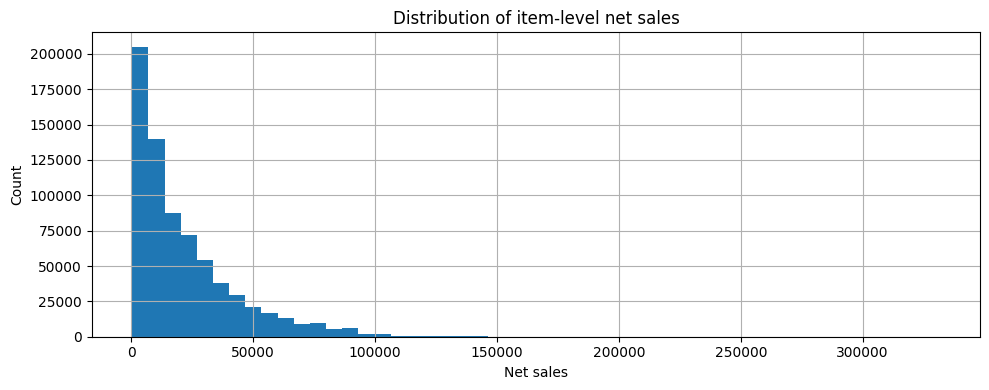

In [11]:
order_items = dfs.get("order_items")

if order_items is not None:
    display(order_items.head())
    display(numeric_summary(order_items))

    required = {"quantity", "unit_price", "discount_amount"}
    if required.issubset(order_items.columns):
        order_items = order_items.copy()
        order_items["gross_sales"] = order_items["quantity"] * order_items["unit_price"]
        order_items["net_sales"] = order_items["gross_sales"] - order_items["discount_amount"].fillna(0)
        order_items["discount_rate"] = order_items["discount_amount"].fillna(0) / order_items["gross_sales"].replace(0, np.nan)

        display(order_items[["quantity", "unit_price", "gross_sales", "discount_amount", "net_sales", "discount_rate"]].describe())

        promo_rate = order_items["promo_id"].notna().mean() * 100 if "promo_id" in order_items.columns else np.nan
        print(f"Promo usage rate based on promo_id: {promo_rate:.2f}%")

        plt.figure(figsize=(10, 4))
        order_items["net_sales"].clip(lower=0).hist(bins=50)
        plt.title("Distribution of item-level net sales")
        plt.xlabel("Net sales")
        plt.ylabel("Count")
        savefig("distribution_item_net_sales.png")
else:
    print("order_items.csv chưa có.")

### 6.3 Payments — payment value & installments

,order_id,payment_method,payment_value,installments
0,1,credit_card,"7,967.54",3
1,2,cod,"71,163.75",1
2,3,credit_card,"33,660.99",3
3,4,credit_card,"53,196.25",3
4,6,paypal,"1,597.84",1


,count,mean,std,min,25%,50%,75%,max
order_id,"646,945.00","417,189.47","240,785.70",1.00,"208,728.00","417,211.00","625,628.00","834,397.00"
payment_value,"646,945.00","24,238.33","22,378.48",389.74,"7,681.06","17,229.44","33,706.35","331,570.40"
installments,"646,945.00",3.45,3.12,1.00,1.00,3.00,6.00,12.00


Saved: outputs\payments_by_method.png


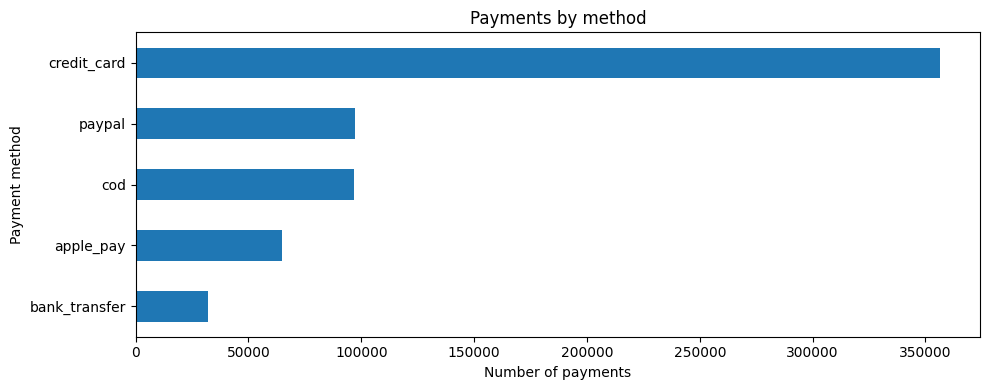

,count,mean,median,sum
installments,,,,
1,262866,"24,113.27","17,088.89","6,338,559,926.85"
2,1094,708.47,722.30,"775,070.26"
3,218949,"24,399.64","17,366.72","5,342,275,790.05"
6,109910,"24,446.65","17,451.97","2,686,931,785.43"
12,54126,"24,245.77","17,336.75","1,312,326,692.84"


Saved: outputs\avg_payment_by_installments.png


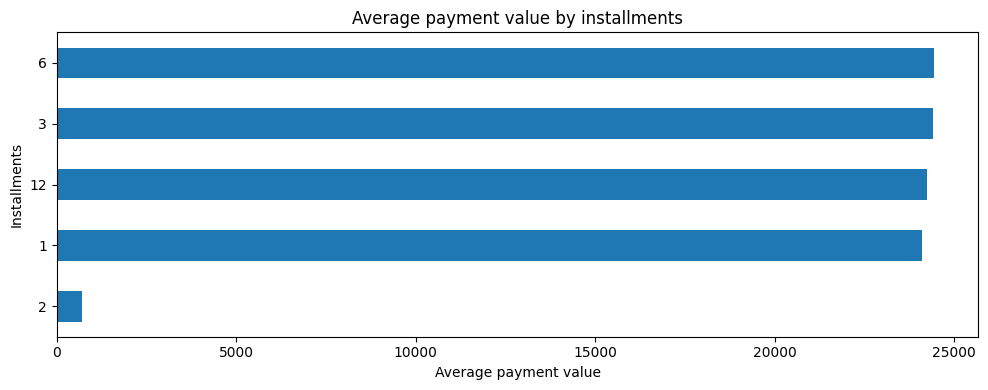

In [12]:
payments = dfs.get("payments")

if payments is not None:
    display(payments.head())
    display(numeric_summary(payments))

    if "payment_method" in payments.columns:
        plot_bar(
            payments["payment_method"].value_counts(),
            "Payments by method",
            xlabel="Number of payments",
            ylabel="Payment method",
            filename="payments_by_method.png"
        )

    if {"installments", "payment_value"}.issubset(payments.columns):
        install = payments.groupby("installments")["payment_value"].agg(["count", "mean", "median", "sum"]).sort_index()
        display(install)

        plot_bar(
            install["mean"].sort_values(ascending=False),
            "Average payment value by installments",
            xlabel="Average payment value",
            ylabel="Installments",
            top_n=None,
            filename="avg_payment_by_installments.png"
        )
else:
    print("payments.csv chưa có.")

### 6.4 Shipments — delivery time, shipping fee

,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79


count   566,067.00
mean          4.50
std           1.71
min           2.00
25%           3.00
50%           4.00
75%           6.00
max           7.00
Name: delivery_days, dtype: float64

Saved: outputs\delivery_days_distribution.png


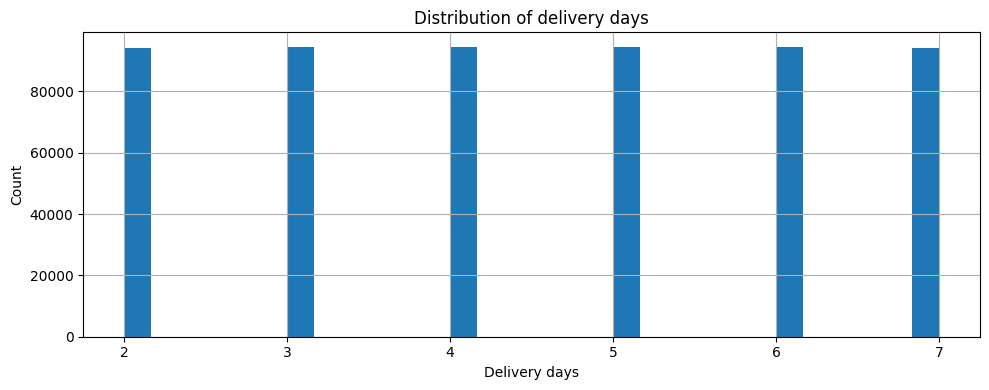

count   566,067.00
mean          4.96
std           8.89
min           0.00
25%           0.87
50%           1.73
75%           2.60
max          32.00
Name: shipping_fee, dtype: float64

In [13]:
shipments = dfs.get("shipments")

if shipments is not None:
    display(shipments.head())

    if {"ship_date", "delivery_date"}.issubset(shipments.columns):
        shipments = shipments.copy()
        shipments["delivery_days"] = (shipments["delivery_date"] - shipments["ship_date"]).dt.days
        display(shipments["delivery_days"].describe())

        plt.figure(figsize=(10, 4))
        shipments["delivery_days"].dropna().clip(lower=0, upper=60).hist(bins=30)
        plt.title("Distribution of delivery days")
        plt.xlabel("Delivery days")
        plt.ylabel("Count")
        savefig("delivery_days_distribution.png")

    if "shipping_fee" in shipments.columns:
        display(shipments["shipping_fee"].describe())
else:
    print("shipments.csv chưa có.")

### 6.5 Returns — return reasons, refund amount

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.01"
1,RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.37"
2,RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.95"
3,RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.75"
4,RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.76"


,table,column,dtype,missing_count,missing_pct,n_unique
4,returns,return_reason,str,0,0.00,5
5,returns,return_quantity,int64,0,0.00,8
2,returns,product_id,int64,0,0.00,1286
3,returns,return_date,datetime64[us],0,0.00,3806
1,returns,order_id,int64,0,0.00,36062
6,returns,refund_amount,float64,0,0.00,39560
0,returns,return_id,str,0,0.00,39939


Saved: outputs\return_reasons.png


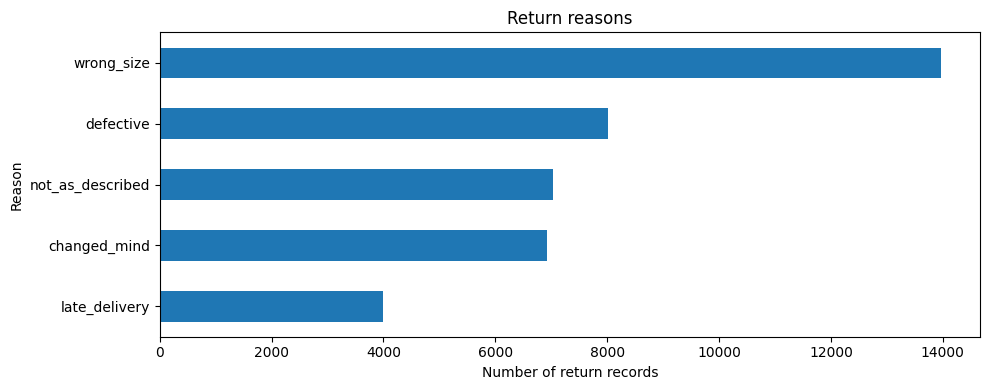

count    39,939.00
mean     12,784.46
std      14,092.15
min         458.81
25%       3,573.39
50%       7,888.88
75%      16,881.99
max     160,937.94
Name: refund_amount, dtype: float64

In [14]:
returns = dfs.get("returns")

if returns is not None:
    display(returns.head())
    display(missing_report(returns, "returns"))

    if "return_reason" in returns.columns:
        plot_bar(
            returns["return_reason"].value_counts(),
            "Return reasons",
            xlabel="Number of return records",
            ylabel="Reason",
            filename="return_reasons.png"
        )

    if "refund_amount" in returns.columns:
        display(returns["refund_amount"].describe())
else:
    print("returns.csv chưa có.")

### 6.6 Reviews — rating distribution

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


Saved: outputs\review_rating_distribution.png


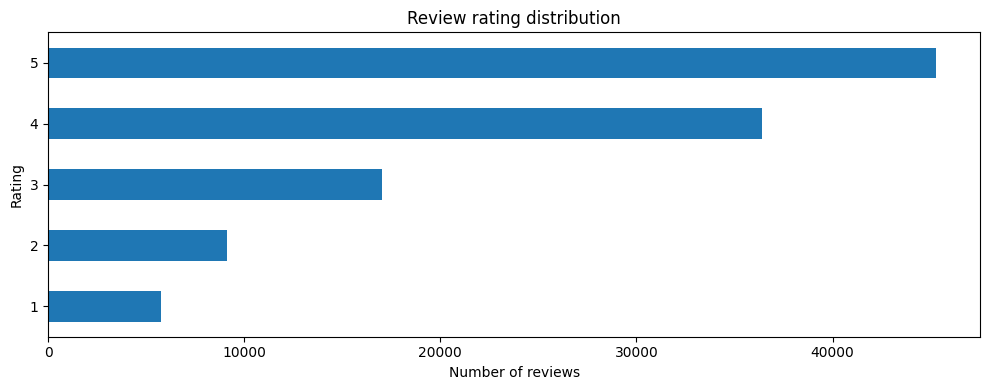

Average rating: 3.9360111315620294


In [15]:
reviews = dfs.get("reviews")

if reviews is not None:
    display(reviews.head())

    if "rating" in reviews.columns:
        rating_counts = reviews["rating"].value_counts().sort_index()
        plot_bar(
            rating_counts,
            "Review rating distribution",
            xlabel="Number of reviews",
            ylabel="Rating",
            top_n=None,
            filename="review_rating_distribution.png"
        )

        print("Average rating:", reviews["rating"].mean())
else:
    print("reviews.csv chưa có.")

## 7 — Analytical: Sales time series

,Date,Revenue,COGS
0,2012-07-04,"5,123,547.94","3,982,991.19"
1,2012-07-05,"2,751,773.45","2,150,580.23"
2,2012-07-06,"3,054,029.42","2,517,632.84"
3,2012-07-07,"2,667,930.94","2,108,246.62"
4,2012-07-08,"2,360,851.90","1,808,622.79"


,Date,Revenue,COGS
count,3833,"3,833.00","3,833.00"
mean,2017-10-02 00:00:00,"4,286,584.03","3,695,134.49"
min,2012-07-04 00:00:00,"279,813.94","236,576.31"
25%,2015-02-17 00:00:00,"2,471,088.82","2,150,580.23"
50%,2017-10-02 00:00:00,"3,647,303.90","3,161,112.99"
75%,2020-05-17 00:00:00,"5,350,877.20","4,637,293.92"
max,2022-12-31 00:00:00,"20,905,271.35","16,535,857.67"
std,NaN,"2,624,840.20","2,219,788.77"


Saved: outputs\daily_revenue.png


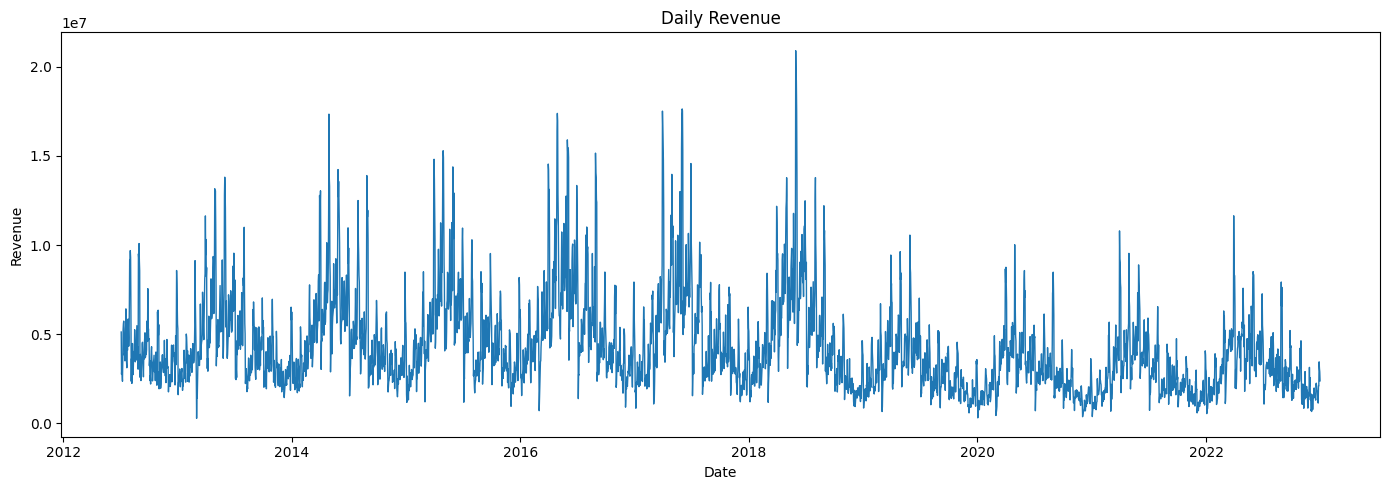

Saved: outputs\monthly_revenue.png


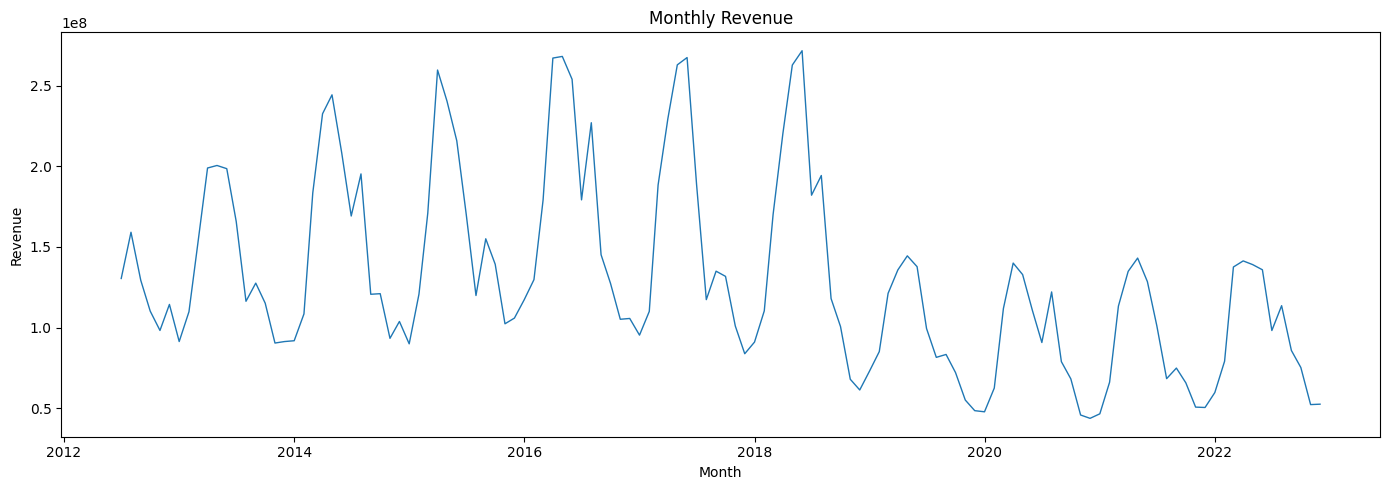

,Revenue,COGS,gross_profit,gross_margin_rate
year,,,,
2012,"741,497,748.02","587,461,923.81","154,035,824.21",0.21
2013,"1,657,169,417.27","1,465,980,103.20","191,189,314.07",0.12
2014,"1,871,845,882.80","1,574,607,456.89","297,238,425.91",0.16
2015,"1,889,933,826.92","1,665,441,817.42","224,492,009.50",0.12
2016,"2,104,640,677.54","1,780,559,392.69","324,081,284.85",0.15
2017,"1,911,164,325.28","1,694,385,793.54","216,778,531.74",0.11
2018,"1,850,122,456.08","1,542,175,766.14","307,946,689.94",0.17
2019,"1,136,801,441.51","1,005,202,883.72","131,598,557.79",0.12
2020,"1,054,512,158.79","886,085,097.63","168,427,061.16",0.16


Saved: outputs\annual_revenue.png


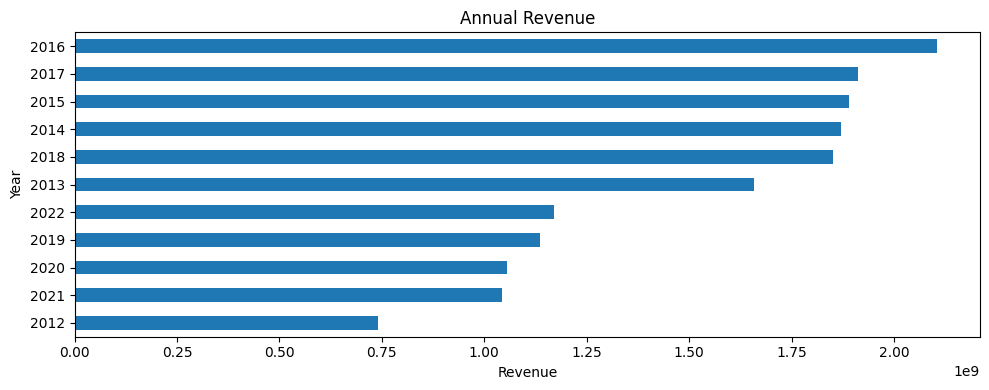

In [16]:
sales = dfs.get("sales")

if sales is not None:
    display(sales.head())
    display(sales.describe())

    if {"Date", "Revenue", "COGS"}.issubset(sales.columns):
        sales = sales.copy()
        sales["gross_profit"] = sales["Revenue"] - sales["COGS"]
        sales["gross_margin_rate"] = sales["gross_profit"] / sales["Revenue"].replace(0, np.nan)
        sales["year"] = sales["Date"].dt.year
        sales["month"] = sales["Date"].dt.month
        sales["year_month"] = sales["Date"].dt.to_period("M").dt.to_timestamp()

        plot_line(
            sales,
            "Date",
            "Revenue",
            "Daily Revenue",
            xlabel="Date",
            ylabel="Revenue",
            filename="daily_revenue.png"
        )

        monthly_sales = (
            sales
            .groupby("year_month")[["Revenue", "COGS", "gross_profit"]]
            .sum()
            .reset_index()
        )

        plot_line(
            monthly_sales,
            "year_month",
            "Revenue",
            "Monthly Revenue",
            xlabel="Month",
            ylabel="Revenue",
            filename="monthly_revenue.png"
        )

        annual_sales = sales.groupby("year")[["Revenue", "COGS", "gross_profit"]].sum()
        annual_sales["gross_margin_rate"] = annual_sales["gross_profit"] / annual_sales["Revenue"]
        display(annual_sales)

        plot_bar(
            annual_sales["Revenue"],
            "Annual Revenue",
            xlabel="Revenue",
            ylabel="Year",
            top_n=None,
            filename="annual_revenue.png"
        )
else:
    print("sales.csv chưa có.")

## 8 — Operational: Inventory & Web Traffic

### 8.1 Inventory — stockout, overstock, sell-through

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.00,0.93,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.00,0.97,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.00,0.97,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.50,0.93,1,1,0,0.24,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.00,0.97,1,1,0,0.22,DragonWear MA-03,Casual,All-weather,2016,5


,count,mean,std,min,25%,50%,75%,max
product_id,"60,247.00","1,311.41",673.05,1.00,760.00,"1,223.00","1,942.00","2,412.00"
stock_on_hand,"60,247.00",189.30,316.98,3.00,15.00,62.00,210.00,"2,673.00"
units_received,"60,247.00",18.05,34.08,1.00,2.00,6.00,19.00,817.00
units_sold,"60,247.00",15.42,28.40,1.00,2.00,6.00,16.00,670.00
stockout_days,"60,247.00",1.16,1.62,0.00,0.00,1.00,2.00,28.00
days_of_supply,"60,247.00",912.68,"2,587.62",5.20,96.00,240.00,683.10,"68,100.00"
fill_rate,"60,247.00",0.96,0.05,0.07,0.93,0.97,1.00,1.00
stockout_flag,"60,247.00",0.67,0.47,0.00,0.00,1.00,1.00,1.00
overstock_flag,"60,247.00",0.76,0.43,0.00,1.00,1.00,1.00,1.00
reorder_flag,"60,247.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00


Saved: outputs\inventory_by_category.png


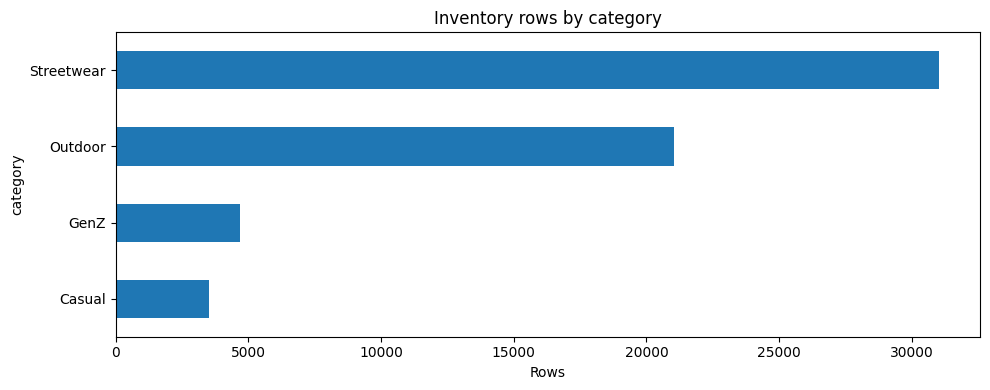

Saved: outputs\inventory_by_segment.png


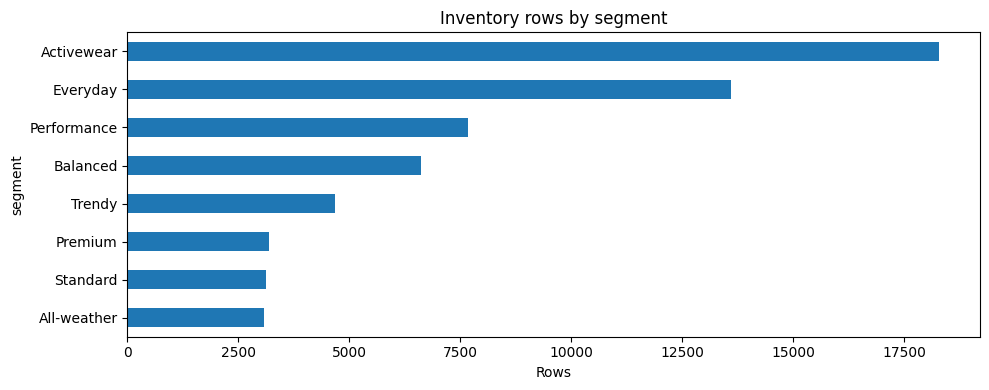

,stockout_flag,overstock_flag,reorder_flag
category,,,
GenZ,0.68,0.72,0.00
Outdoor,0.67,0.80,0.00
Streetwear,0.67,0.75,0.00
Casual,0.66,0.73,0.00


Saved: outputs\stockout_rate_by_category.png


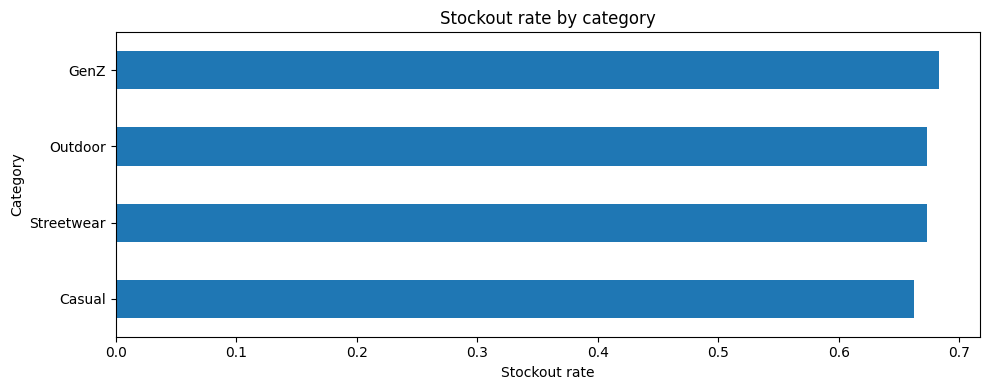

Saved: outputs\sell_through_rate_distribution.png


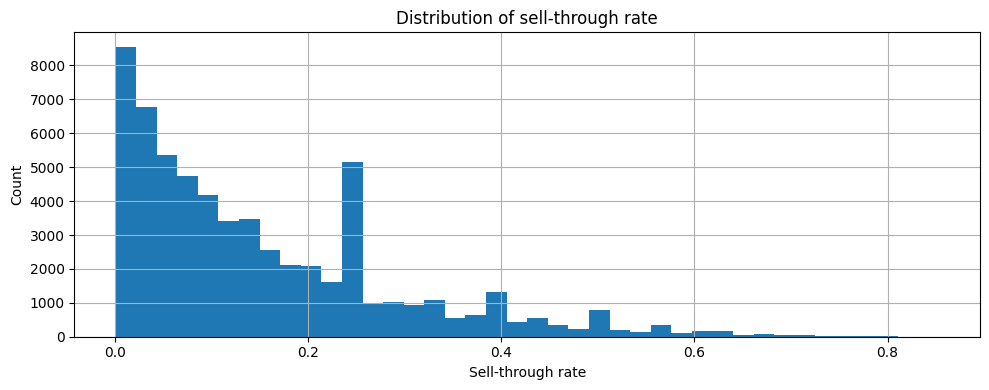

In [17]:
inventory = dfs.get("inventory")

if inventory is not None:
    display(inventory.head())
    display(numeric_summary(inventory))

    for col in ["category", "segment"]:
        if col in inventory.columns:
            plot_bar(
                inventory[col].value_counts(),
                f"Inventory rows by {col}",
                xlabel="Rows",
                ylabel=col,
                filename=f"inventory_by_{col}.png"
            )

    if {"category", "stockout_flag", "overstock_flag", "reorder_flag"}.issubset(inventory.columns):
        inventory_kpi = inventory.groupby("category")[["stockout_flag", "overstock_flag", "reorder_flag"]].mean().sort_values("stockout_flag", ascending=False)
        display(inventory_kpi)

        plot_bar(
            inventory_kpi["stockout_flag"],
            "Stockout rate by category",
            xlabel="Stockout rate",
            ylabel="Category",
            filename="stockout_rate_by_category.png"
        )

    if "sell_through_rate" in inventory.columns:
        plt.figure(figsize=(10, 4))
        inventory["sell_through_rate"].dropna().hist(bins=40)
        plt.title("Distribution of sell-through rate")
        plt.xlabel("Sell-through rate")
        plt.ylabel("Count")
        savefig("sell_through_rate_distribution.png")
else:
    print("inventory.csv chưa có.")

### 8.2 Web Traffic — sessions, bounce rate, traffic source

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.01,102.90,organic_search
1,2013-01-02,10456,8151,47611,0.00,120.50,organic_search
2,2013-01-03,10076,7458,36963,0.00,263.60,direct
3,2013-01-04,9973,8063,53078,0.01,151.80,direct
4,2013-01-05,10223,7882,36790,0.01,168.60,referral


,count,mean,std,min,25%,50%,75%,max
sessions,"3,652.00","25,041.77","9,422.61","7,973.00","17,099.25","23,633.50","31,782.75","50,947.00"
unique_visitors,"3,652.00","19,031.40","7,237.95","6,136.00","12,915.00","17,924.00","24,191.75","40,430.00"
page_views,"3,652.00","108,615.22","44,472.06","30,451.00","72,982.00","101,010.50","138,086.00","275,560.00"
bounce_rate,"3,652.00",0.00,0.00,0.00,0.00,0.00,0.01,0.01
avg_session_duration_sec,"3,652.00",210.28,63.77,100.10,156.70,209.20,266.20,319.90


Saved: outputs\traffic_records_by_source.png


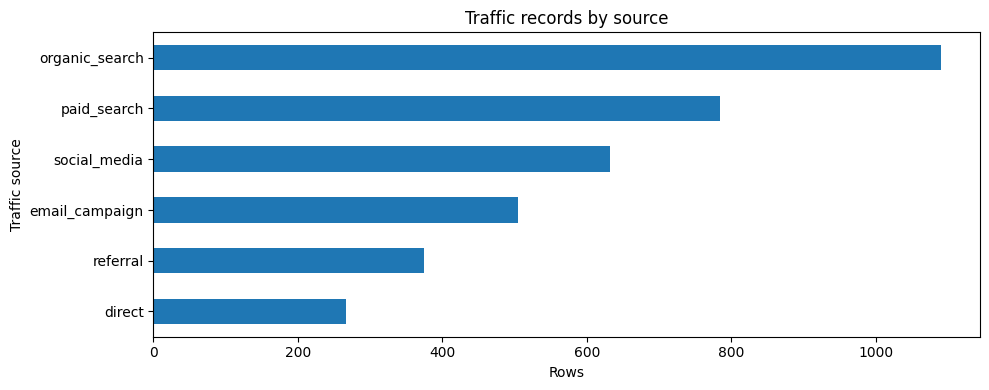

Saved: outputs\daily_sessions.png


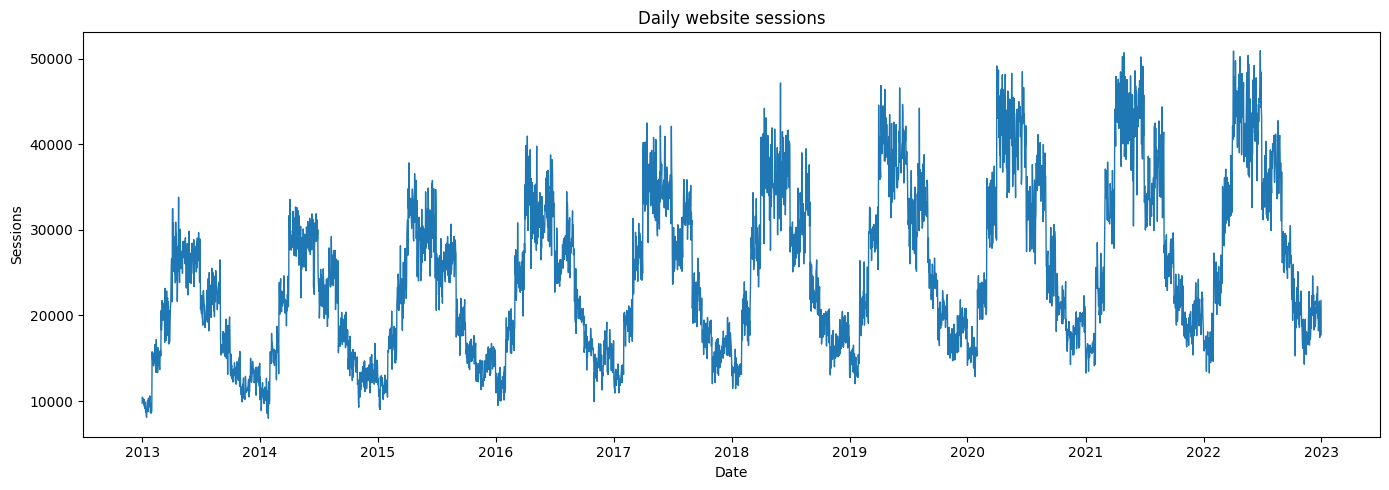

Saved: outputs\avg_bounce_rate_by_source.png


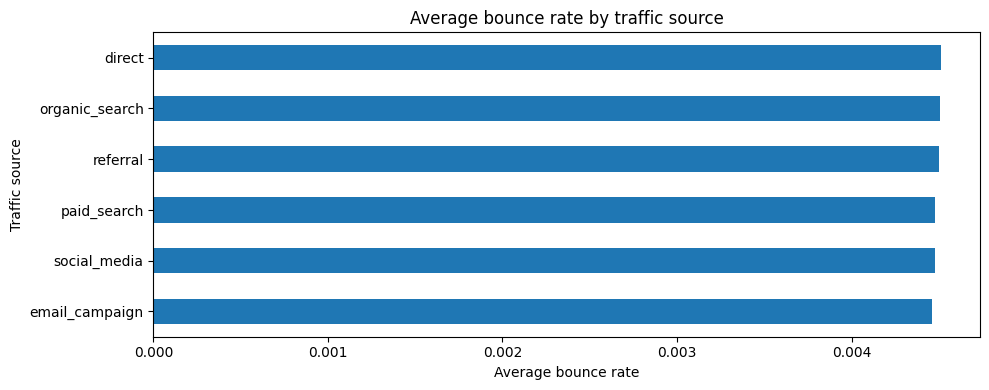

In [18]:
web_traffic = dfs.get("web_traffic")

if web_traffic is not None:
    display(web_traffic.head())
    display(numeric_summary(web_traffic))

    if "traffic_source" in web_traffic.columns:
        plot_bar(
            web_traffic["traffic_source"].value_counts(),
            "Traffic records by source",
            xlabel="Rows",
            ylabel="Traffic source",
            filename="traffic_records_by_source.png"
        )

    if {"date", "sessions"}.issubset(web_traffic.columns):
        daily_web = web_traffic.groupby("date")["sessions"].sum().reset_index()
        plot_line(
            daily_web,
            "date",
            "sessions",
            "Daily website sessions",
            xlabel="Date",
            ylabel="Sessions",
            filename="daily_sessions.png"
        )

    if {"traffic_source", "bounce_rate"}.issubset(web_traffic.columns):
        bounce_by_source = web_traffic.groupby("traffic_source")["bounce_rate"].mean().sort_values()
        plot_bar(
            bounce_by_source,
            "Average bounce rate by traffic source",
            xlabel="Average bounce rate",
            ylabel="Traffic source",
            filename="avg_bounce_rate_by_source.png"
        )
else:
    print("web_traffic.csv chưa có.")

## 9 — Joined analysis: tạo bảng phân tích đơn hàng đầy đủ

In [19]:
# Build transaction-level analytical table
orders = dfs.get("orders")
order_items = dfs.get("order_items")
products = dfs.get("products")
customers = dfs.get("customers")
geography = dfs.get("geography")
payments = dfs.get("payments")
returns = dfs.get("returns")
reviews = dfs.get("reviews")
shipments = dfs.get("shipments")

order_item_fact = None

if orders is not None and order_items is not None:
    temp_items = order_items.copy()

    if {"quantity", "unit_price", "discount_amount"}.issubset(temp_items.columns):
        temp_items["gross_sales"] = temp_items["quantity"] * temp_items["unit_price"]
        temp_items["net_sales"] = temp_items["gross_sales"] - temp_items["discount_amount"].fillna(0)

    order_item_fact = temp_items.merge(orders, on="order_id", how="left", suffixes=("", "_order"))

    if products is not None and "product_id" in temp_items.columns and "product_id" in products.columns:
        product_cols = ["product_id"] + [c for c in ["product_name", "category", "segment", "size", "color", "price", "cogs"] if c in products.columns]
        order_item_fact = order_item_fact.merge(products[product_cols], on="product_id", how="left")

    if customers is not None and "customer_id" in order_item_fact.columns and "customer_id" in customers.columns:
        customer_cols = ["customer_id"] + [c for c in ["gender", "age_group", "acquisition_channel", "signup_date"] if c in customers.columns]
        order_item_fact = order_item_fact.merge(customers[customer_cols], on="customer_id", how="left", suffixes=("", "_customer"))

    if geography is not None and "zip" in order_item_fact.columns and "zip" in geography.columns:
        geo_cols = ["zip"] + [c for c in ["city", "region", "district"] if c in geography.columns]
        order_item_fact = order_item_fact.merge(geography[geo_cols], on="zip", how="left", suffixes=("", "_geo"))

    print("order_item_fact shape:", order_item_fact.shape)
    display(order_item_fact.head())

    order_item_fact.to_csv(OUTPUT_DIR / "order_item_fact_sample.csv", index=False)
else:
    print("Không đủ orders.csv và order_items.csv để tạo order_item_fact.")

order_item_fact shape: (714669, 30)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,gross_sales,net_sales,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs,gender,age_group,acquisition_channel,signup_date,city,region,district
0,1,2400,7,"1,138.22",0.00,NaN,NaN,"7,967.54","7,967.54",2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.26","1,053.80",Female,35-44,social_media,2020-06-06,Hanoi,East,District #02
1,2,609,7,"10,166.25",0.00,NaN,NaN,"71,163.75","71,163.75",2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70",Female,18-24,social_media,2021-11-03,Phu Ly,East,District #02
2,3,396,3,"11,220.33",0.00,NaN,NaN,"33,660.99","33,660.99",2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.43","10,091.01",Female,35-44,direct,2020-09-18,Lao Cai,East,District #02
3,4,635,5,"10,639.25",0.00,NaN,NaN,"53,196.25","53,196.25",2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.22","9,205.43",Male,45-54,direct,2016-05-29,Son Tay,East,District #02
4,6,1935,1,"1,597.84",0.00,NaN,NaN,"1,597.84","1,597.84",2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.91","1,048.70",Male,18-24,social_media,2017-07-11,Uong Bi,East,District #02


## 10 — Business Insights: Revenue, customers, products, regions

### 10.1 Revenue by category/segment/region

,net_sales
category,
Streetwear,"12,558,477,099.17"
Outdoor,"2,353,396,796.86"
Casual,"440,285,193.75"
GenZ,"328,710,175.65"


Saved: outputs\net_sales_by_category.png


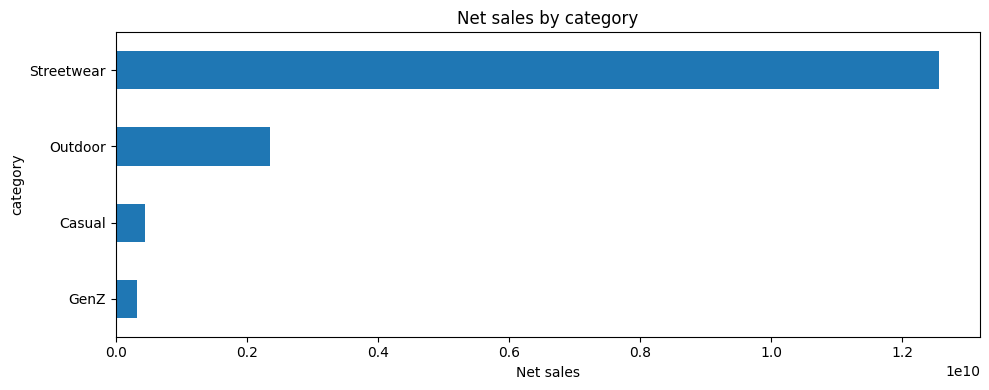

,net_sales
segment,
Everyday,"5,147,454,916.61"
Balanced,"4,900,317,965.89"
Performance,"2,285,029,332.18"
Activewear,"1,930,704,974.66"
Premium,"454,211,900.54"
All-weather,"408,765,115.41"
Trendy,"328,710,175.65"
Standard,"225,674,884.49"


Saved: outputs\net_sales_by_segment.png


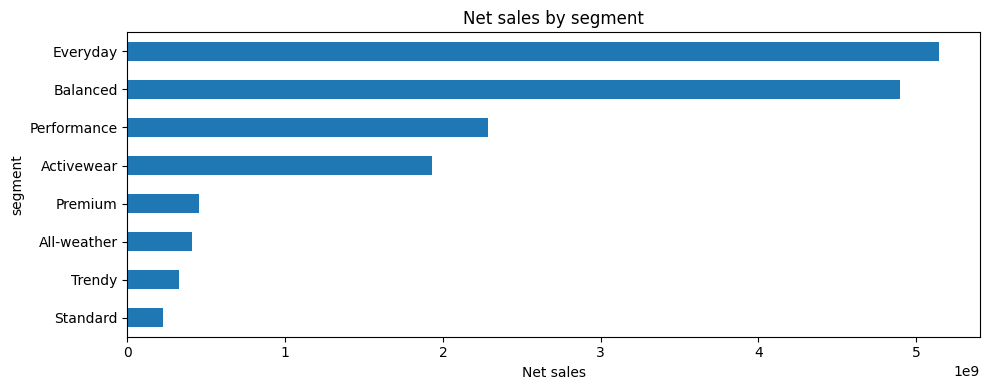

,net_sales
region,
East,"7,291,150,819.12"
Central,"4,719,491,267.84"
West,"3,670,227,178.47"


Saved: outputs\net_sales_by_region.png


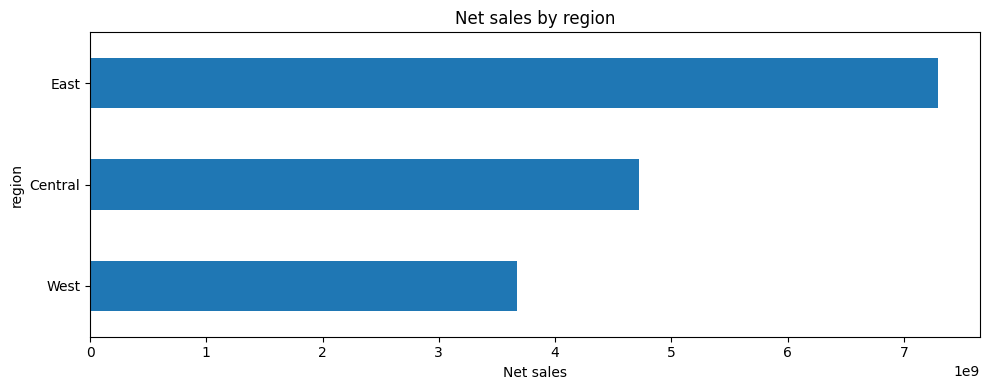

,net_sales
order_source,
organic_search,"4,385,324,881.54"
paid_search,"3,441,964,418.44"
social_media,"3,141,153,470.29"
email_campaign,"1,882,479,280.82"
referral,"1,565,897,314.00"
direct,"1,264,049,900.34"


Saved: outputs\net_sales_by_order_source.png


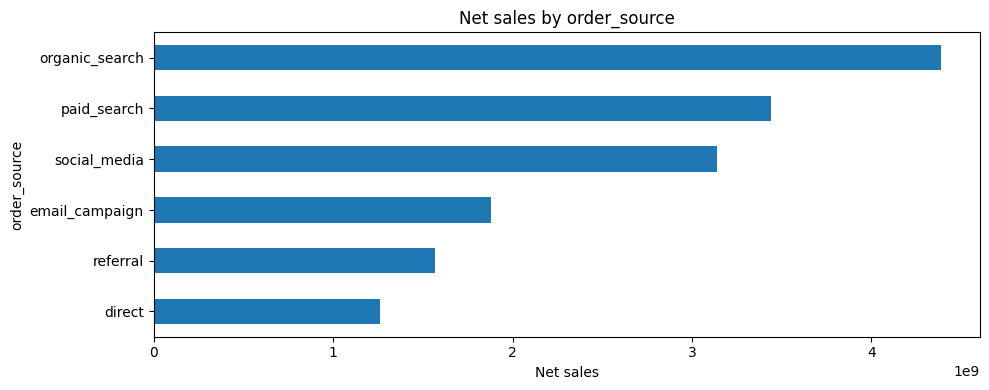

,net_sales
device_type,
mobile,"7,066,788,763.16"
desktop,"6,265,041,337.58"
tablet,"2,349,039,164.69"


Saved: outputs\net_sales_by_device_type.png


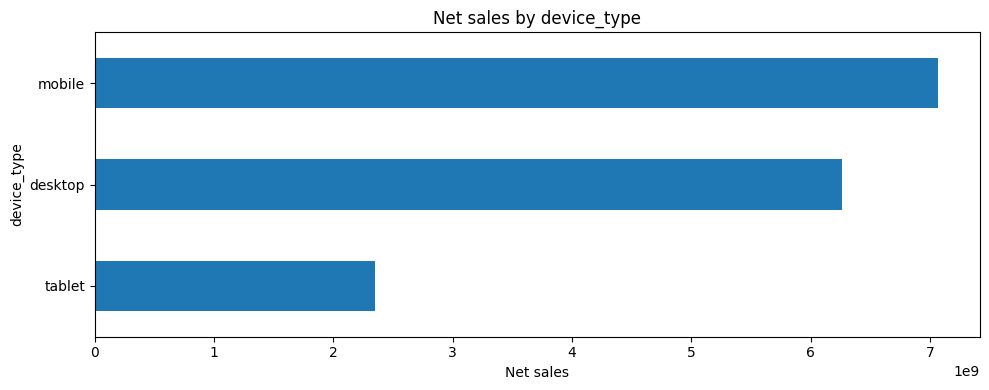

,net_sales
payment_method,
credit_card,"8,630,069,413.19"
paypal,"2,363,680,137.73"
cod,"2,346,947,592.93"
apple_pay,"1,564,269,610.50"
bank_transfer,"775,902,511.08"


Saved: outputs\net_sales_by_payment_method.png


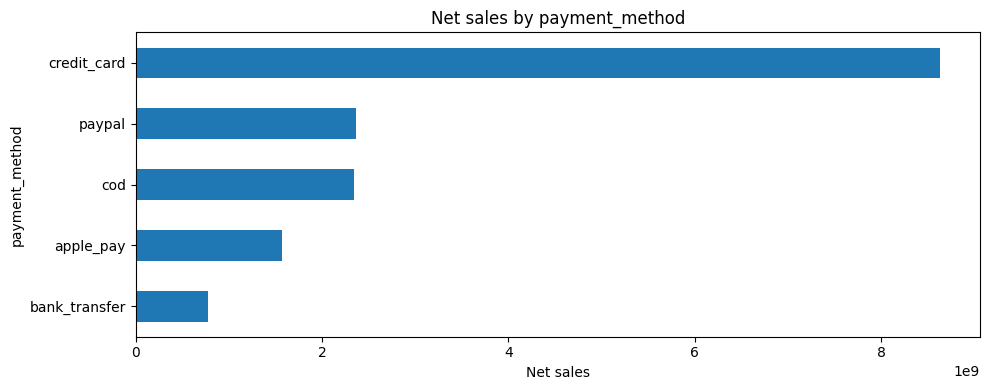

In [20]:
if order_item_fact is not None and "net_sales" in order_item_fact.columns:
    for col in ["category", "segment", "region", "order_source", "device_type", "payment_method"]:
        if col in order_item_fact.columns:
            revenue_by_col = (
                order_item_fact
                .groupby(col)["net_sales"]
                .sum()
                .sort_values(ascending=False)
            )

            display(pd.DataFrame(revenue_by_col))

            plot_bar(
                revenue_by_col,
                f"Net sales by {col}",
                xlabel="Net sales",
                ylabel=col,
                top_n=20,
                filename=f"net_sales_by_{col}.png"
            )
else:
    print("Chưa có order_item_fact hoặc net_sales.")

### 10.2 Margin by product category/segment

,net_sales,estimated_cogs,gross_profit,gross_margin_rate
category,,,,
GenZ,"328,710,175.65","277,873,798.15","50,836,377.50",0.15
Outdoor,"2,353,396,796.86","2,086,362,704.84","267,034,092.02",0.11
Streetwear,"12,558,477,099.17","11,392,669,587.62","1,165,807,511.55",0.09
Casual,"440,285,193.75","406,544,428.52","33,740,765.23",0.08


Saved: outputs\gross_margin_rate_by_category.png


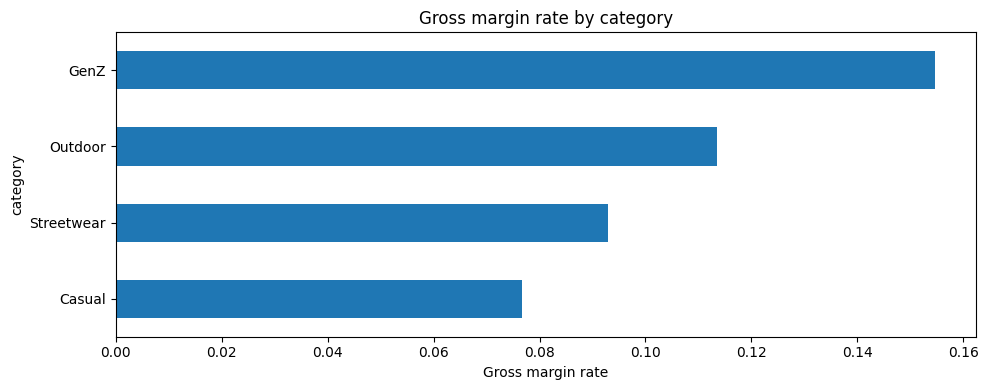

,net_sales,estimated_cogs,gross_profit,gross_margin_rate
segment,,,,
Trendy,"328,710,175.65","277,873,798.15","50,836,377.50",0.15
Activewear,"1,930,704,974.66","1,684,365,425.47","246,339,549.19",0.13
Standard,"225,674,884.49","196,972,029.58","28,702,854.91",0.13
Everyday,"5,147,454,916.61","4,615,280,157.29","532,174,759.32",0.10
Balanced,"4,900,317,965.89","4,469,081,905.23","431,236,060.66",0.09
Performance,"2,285,029,332.18","2,111,335,495.52","173,693,836.66",0.08
All-weather,"408,765,115.41","380,916,033.48","27,849,081.93",0.07
Premium,"454,211,900.54","427,625,674.40","26,586,226.14",0.06


Saved: outputs\gross_margin_rate_by_segment.png


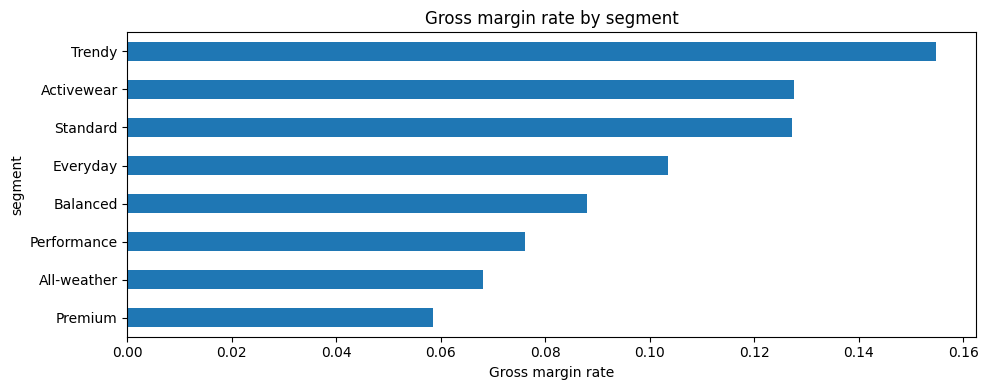

In [21]:
if order_item_fact is not None:
    if {"quantity", "cogs", "net_sales"}.issubset(order_item_fact.columns):
        fact = order_item_fact.copy()
        fact["estimated_cogs"] = fact["quantity"] * fact["cogs"]
        fact["gross_profit"] = fact["net_sales"] - fact["estimated_cogs"]

        for col in ["category", "segment"]:
            if col in fact.columns:
                margin = fact.groupby(col)[["net_sales", "estimated_cogs", "gross_profit"]].sum()
                margin["gross_margin_rate"] = margin["gross_profit"] / margin["net_sales"]
                margin = margin.sort_values("gross_margin_rate", ascending=False)

                display(margin)

                plot_bar(
                    margin["gross_margin_rate"],
                    f"Gross margin rate by {col}",
                    xlabel="Gross margin rate",
                    ylabel=col,
                    filename=f"gross_margin_rate_by_{col}.png"
                )
    else:
        print("Thiếu quantity/cogs/net_sales để tính margin.")
else:
    print("Chưa có order_item_fact.")

### 10.3 Return rate by category/segment/size

,order_item_lines,return_records,return_rate
category,,,
GenZ,37159,2126,0.06
Outdoor,259986,14720,0.06
Streetwear,393533,21799,0.06
Casual,23991,1294,0.05


Saved: outputs\return_rate_by_category.png


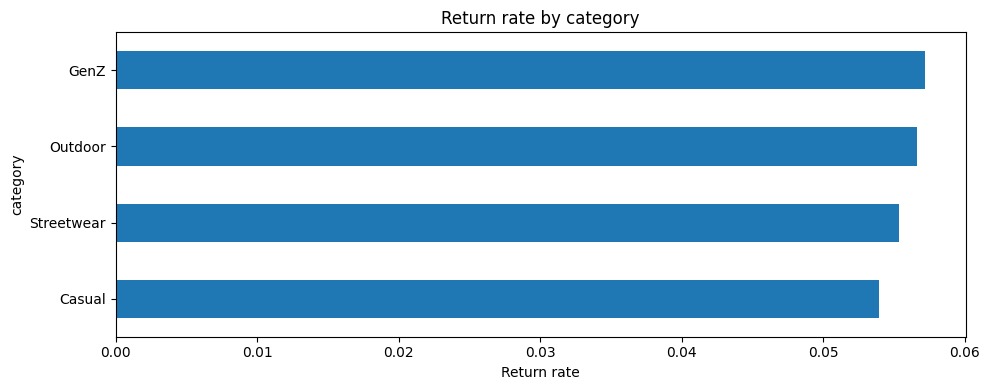

,order_item_lines,return_records,return_rate
segment,,,
Trendy,37159,2126,0.06
Activewear,230375,13085,0.06
Performance,96730,5442,0.06
Everyday,182533,10143,0.06
Premium,31032,1722,0.06
Standard,10937,601,0.05
Balanced,103333,5613,0.05
All-weather,22570,1207,0.05


Saved: outputs\return_rate_by_segment.png


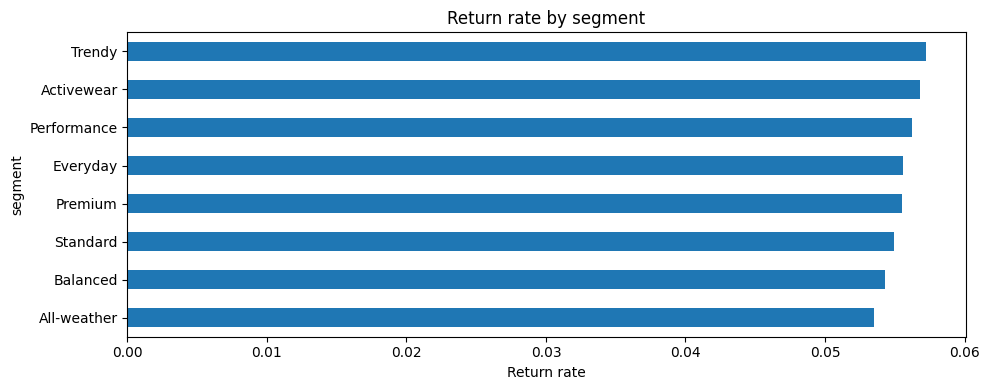

,order_item_lines,return_records,return_rate
size,,,
S,172042,9723,0.06
L,173174,9741,0.06
M,176428,9820,0.06
XL,193025,10655,0.06


Saved: outputs\return_rate_by_size.png


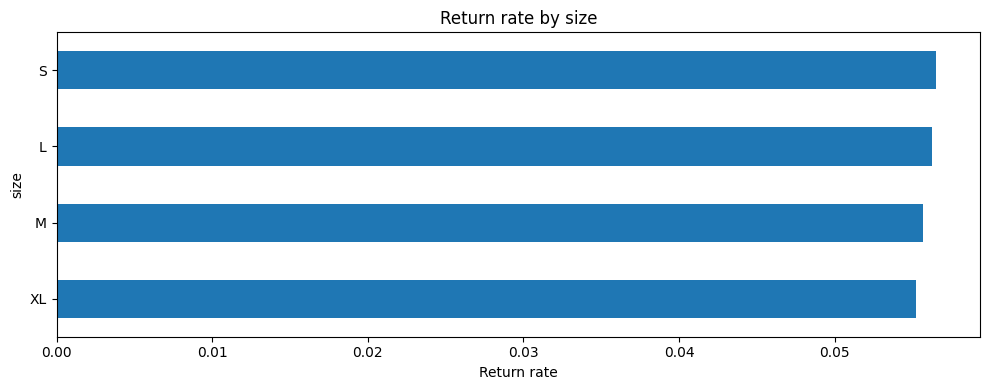

In [22]:
if order_items is not None and products is not None and returns is not None:
    item_prod = order_items.merge(
        products[[c for c in ["product_id", "category", "segment", "size"] if c in products.columns]],
        on="product_id",
        how="left"
    )

    return_prod = returns.merge(
        products[[c for c in ["product_id", "category", "segment", "size"] if c in products.columns]],
        on="product_id",
        how="left"
    )

    for col in ["category", "segment", "size"]:
        if col in item_prod.columns and col in return_prod.columns:
            denom = item_prod.groupby(col).size().rename("order_item_lines")
            numer = return_prod.groupby(col).size().rename("return_records")
            rr = pd.concat([denom, numer], axis=1).fillna(0)
            rr["return_rate"] = rr["return_records"] / rr["order_item_lines"]
            rr = rr.sort_values("return_rate", ascending=False)

            display(rr)

            plot_bar(
                rr["return_rate"],
                f"Return rate by {col}",
                xlabel="Return rate",
                ylabel=col,
                top_n=20,
                filename=f"return_rate_by_{col}.png"
            )
else:
    print("Cần order_items.csv, products.csv, returns.csv để phân tích return rate.")

### 10.4 Customer repeat behavior & inter-order gap

Repeat customer rate: 75.23%
Median inter-order gap: 144.00 days
Saved: outputs\inter_order_gap_distribution.png


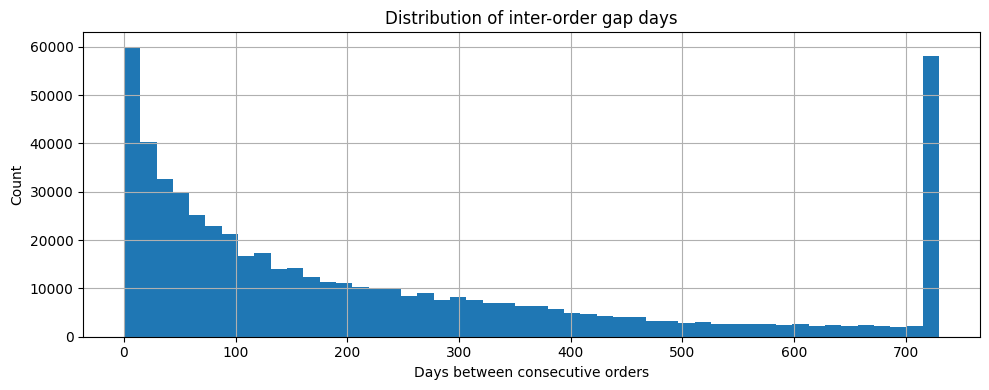

,orders
count,"90,246.00"
mean,7.17
std,8.63
min,1.00
25%,2.00
50%,4.00
75%,9.00
max,107.00


In [23]:
if orders is not None and {"customer_id", "order_date", "order_id"}.issubset(orders.columns):
    cust_orders = orders.sort_values(["customer_id", "order_date"]).copy()
    cust_orders["inter_order_gap_days"] = cust_orders.groupby("customer_id")["order_date"].diff().dt.days

    order_count_by_customer = cust_orders.groupby("customer_id")["order_id"].count()
    repeat_rate = (order_count_by_customer > 1).mean() * 100
    median_gap = cust_orders["inter_order_gap_days"].dropna().median()

    print(f"Repeat customer rate: {repeat_rate:.2f}%")
    print(f"Median inter-order gap: {median_gap:.2f} days")

    plt.figure(figsize=(10, 4))
    cust_orders["inter_order_gap_days"].dropna().clip(upper=730).hist(bins=50)
    plt.title("Distribution of inter-order gap days")
    plt.xlabel("Days between consecutive orders")
    plt.ylabel("Count")
    savefig("inter_order_gap_distribution.png")

    customer_kpi = pd.DataFrame({
        "orders": order_count_by_customer,
    })
    customer_kpi["is_repeat_customer"] = customer_kpi["orders"] > 1
    display(customer_kpi.describe())
else:
    print("Thiếu cột cần thiết trong orders.csv.")

### 10.5 Delivery performance vs reviews/returns

delivery_bucket
0-2    3.94
3-5    3.94
6-10   3.93
Name: rating, dtype: float64

Saved: outputs\avg_rating_by_delivery_bucket.png


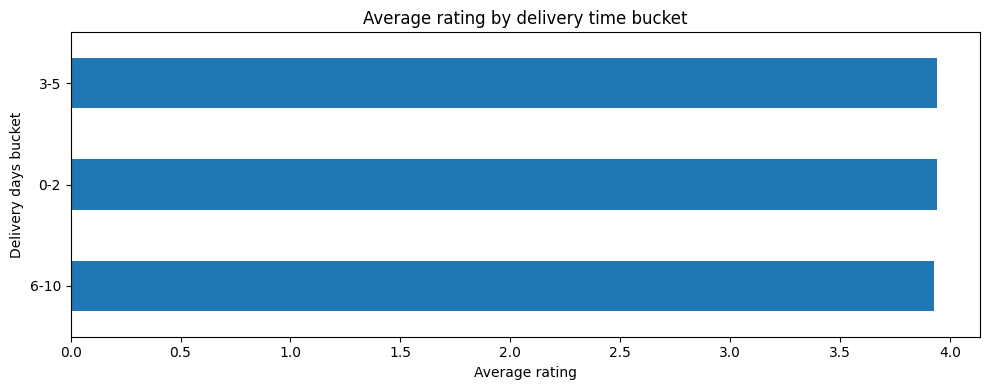

In [24]:
# Delivery speed and rating relationship
if shipments is not None and reviews is not None:
    if {"order_id", "ship_date", "delivery_date"}.issubset(shipments.columns) and {"order_id", "rating"}.issubset(reviews.columns):
        ship = shipments.copy()
        ship["delivery_days"] = (ship["delivery_date"] - ship["ship_date"]).dt.days

        delivery_reviews = reviews.merge(ship[["order_id", "delivery_days"]], on="order_id", how="left")
        delivery_reviews = delivery_reviews.dropna(subset=["delivery_days", "rating"])

        if len(delivery_reviews) > 0:
            rating_by_delivery = (
                delivery_reviews
                .assign(delivery_bucket=pd.cut(delivery_reviews["delivery_days"], bins=[-1, 2, 5, 10, 20, 999], labels=["0-2", "3-5", "6-10", "11-20", "20+"]))
                .groupby("delivery_bucket")["rating"]
                .mean()
            )

            display(rating_by_delivery)

            plot_bar(
                rating_by_delivery,
                "Average rating by delivery time bucket",
                xlabel="Average rating",
                ylabel="Delivery days bucket",
                top_n=None,
                filename="avg_rating_by_delivery_bucket.png"
            )
        else:
            print("Không có dữ liệu giao giữa shipments và reviews.")
else:
    print("Cần shipments.csv và reviews.csv.")

## 11 — Web traffic vs sales

sales_web shape: (3652, 8)


,Date,Revenue,COGS,date,sessions,unique_visitors,page_views,bounce_rate
0,2013-01-01,"5,304,546.99","4,156,070.20",2013-01-01,9760,7253,39093,0.01
1,2013-01-02,"1,606,940.44","1,237,497.84",2013-01-02,10456,8151,47611,0.00
2,2013-01-03,"2,281,680.01","1,832,133.02",2013-01-03,10076,7458,36963,0.00
3,2013-01-04,"2,376,895.46","1,940,747.07",2013-01-04,9973,8063,53078,0.01
4,2013-01-05,"2,509,462.77","1,977,027.71",2013-01-05,10223,7882,36790,0.01


,Revenue,COGS,sessions,unique_visitors,page_views,bounce_rate
Revenue,1.00,0.98,0.32,0.32,0.30,-0.02
COGS,0.98,1.00,0.32,0.32,0.30,-0.03
sessions,0.32,0.32,1.00,0.99,0.92,-0.00
unique_visitors,0.32,0.32,0.99,1.00,0.91,-0.00
page_views,0.30,0.30,0.92,0.91,1.00,0.01
bounce_rate,-0.02,-0.03,-0.00,-0.00,0.01,1.00


Saved: outputs\correlation_sales_web_traffic.png


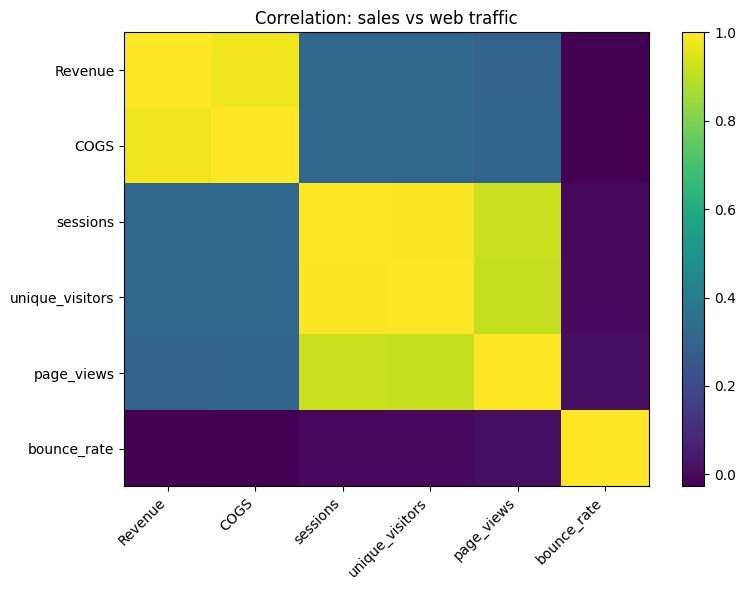

Saved: outputs\revenue_vs_sessions.png


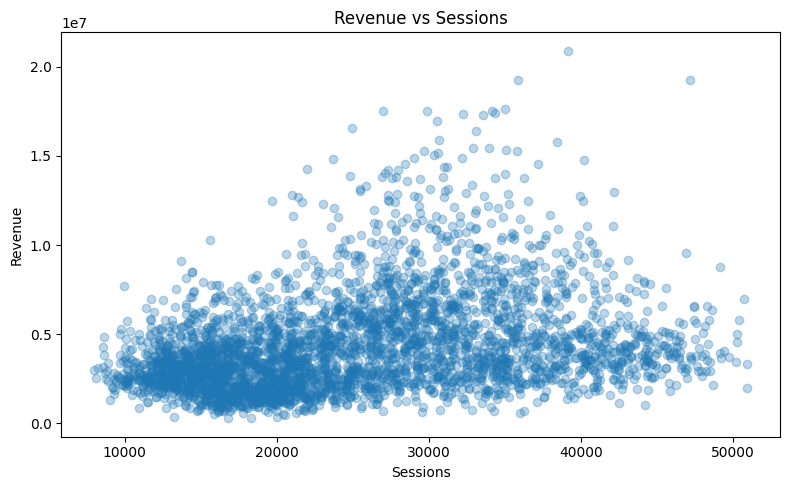

In [25]:
sales = dfs.get("sales")
web_traffic = dfs.get("web_traffic")

if sales is not None and web_traffic is not None:
    if {"Date", "Revenue"}.issubset(sales.columns) and {"date", "sessions", "unique_visitors", "page_views", "bounce_rate"}.issubset(web_traffic.columns):
        daily_web = (
            web_traffic
            .groupby("date")
            .agg({
                "sessions": "sum",
                "unique_visitors": "sum",
                "page_views": "sum",
                "bounce_rate": "mean",
            })
            .reset_index()
        )

        sales_web = sales.merge(daily_web, left_on="Date", right_on="date", how="inner")
        print("sales_web shape:", sales_web.shape)
        display(sales_web.head())

        corr_cols = ["Revenue", "COGS", "sessions", "unique_visitors", "page_views", "bounce_rate"]
        corr_cols = [c for c in corr_cols if c in sales_web.columns]
        corr = sales_web[corr_cols].corr()
        display(corr)

        plt.figure(figsize=(8, 6))
        plt.imshow(corr, aspect="auto")
        plt.colorbar()
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
        plt.yticks(range(len(corr.index)), corr.index)
        plt.title("Correlation: sales vs web traffic")
        savefig("correlation_sales_web_traffic.png")

        plt.figure(figsize=(8, 5))
        plt.scatter(sales_web["sessions"], sales_web["Revenue"], alpha=0.3)
        plt.title("Revenue vs Sessions")
        plt.xlabel("Sessions")
        plt.ylabel("Revenue")
        savefig("revenue_vs_sessions.png")
    else:
        print("Thiếu cột cần thiết để join sales và web_traffic.")
else:
    print("Cần sales.csv và web_traffic.csv.")

## 12 — Inventory vs sales proxy

,month,category,units_sold,stockout_days,stockout_rate,avg_sell_through
0,2012-07-01,Casual,158,19,0.75,0.24
1,2012-07-01,GenZ,416,19,0.80,0.24
2,2012-07-01,Outdoor,2577,137,0.60,0.24
3,2012-07-01,Streetwear,4300,227,0.70,0.24
4,2012-08-01,Casual,185,13,0.53,0.27


Saved: outputs\inventory_stockout_by_category.png


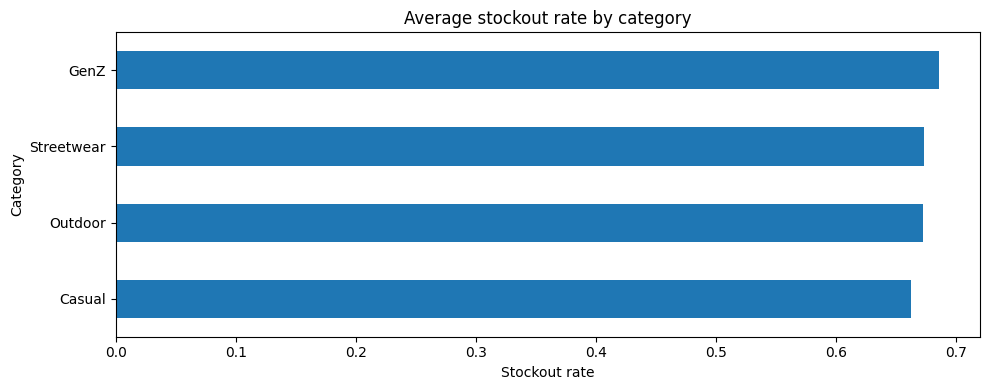

In [26]:
inventory = dfs.get("inventory")

if inventory is not None:
    if {"snapshot_date", "category", "units_sold", "stockout_days", "stockout_flag", "sell_through_rate"}.issubset(inventory.columns):
        inv_monthly_cat = (
            inventory
            .assign(month=lambda x: x["snapshot_date"].dt.to_period("M").dt.to_timestamp())
            .groupby(["month", "category"])
            .agg(
                units_sold=("units_sold", "sum"),
                stockout_days=("stockout_days", "sum"),
                stockout_rate=("stockout_flag", "mean"),
                avg_sell_through=("sell_through_rate", "mean"),
            )
            .reset_index()
        )

        display(inv_monthly_cat.head())

        top_stockout = (
            inv_monthly_cat
            .groupby("category")["stockout_rate"]
            .mean()
            .sort_values(ascending=False)
        )

        plot_bar(
            top_stockout,
            "Average stockout rate by category",
            xlabel="Stockout rate",
            ylabel="Category",
            filename="inventory_stockout_by_category.png"
        )
    else:
        print("Thiếu cột cần thiết trong inventory.csv.")
else:
    print("inventory.csv chưa có.")

## 13 — Outlier detection cơ bản

In [27]:
def iqr_outlier_report(df, table_name):
    if df is None:
        return pd.DataFrame()

    rows = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        s = df[col].dropna()
        if len(s) < 10:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = ((s < lower) | (s > upper)).sum()

        rows.append({
            "table": table_name,
            "column": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(outliers),
            "outlier_pct": round(outliers / len(s) * 100, 2),
        })

    return pd.DataFrame(rows)

outlier_reports = []
for name, df in dfs.items():
    if df is not None:
        outlier_reports.append(iqr_outlier_report(df, name))

outlier_all = pd.concat(outlier_reports, ignore_index=True) if outlier_reports else pd.DataFrame()
outlier_all.sort_values("outlier_pct", ascending=False).head(50)

,table,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
6,promotions,stackable_flag,0.00,0.00,0.00,0.00,0.00,12,24.00
42,inventory,overstock_flag,1.00,1.00,0.00,1.00,1.00,14305,23.74
16,order_items,discount_amount,0.00,967.63,967.63,"-1,451.44","2,419.07",105767,14.80
21,shipments,shipping_fee,0.87,2.60,1.73,-1.72,5.20,76050,13.43
39,inventory,days_of_supply,96.00,683.10,587.10,-784.65,"1,563.75",7455,12.37
35,inventory,stock_on_hand,15.00,210.00,195.00,-277.50,502.50,6432,10.68
36,inventory,units_received,2.00,19.00,17.00,-23.50,44.50,6392,10.61
37,inventory,units_sold,2.00,16.00,14.00,-19.00,37.00,6388,10.60
5,promotions,discount_value,12.00,20.00,8.00,0.00,32.00,5,10.00
25,returns,refund_amount,"3,573.39","16,881.99","13,308.59","-16,389.50","36,844.88",2778,6.96


In [28]:
outlier_all.to_csv(OUTPUT_DIR / "outlier_report.csv", index=False)
print("Saved:", OUTPUT_DIR / "outlier_report.csv")

Saved: outputs\outlier_report.csv


## 14 — MCQ helper: tính nhanh Q1-Q10

In [29]:
def closest_option(value, options):
    return min(options.items(), key=lambda x: abs(value - x[1]))

mcq_results = []

# Q1
try:
    if orders is not None and {"customer_id", "order_date"}.issubset(orders.columns):
        q1_orders = orders.sort_values(["customer_id", "order_date"]).copy()
        q1_orders["gap"] = q1_orders.groupby("customer_id")["order_date"].diff().dt.days
        value = q1_orders["gap"].dropna().median()
        ans, approx = closest_option(value, {"A": 30, "B": 90, "C": 144, "D": 365})
        mcq_results.append(["Q1", value, ans, f"closest={approx}"])
except Exception as e:
    mcq_results.append(["Q1", None, None, str(e)])

# Q2
try:
    if products is not None and {"segment", "price", "cogs"}.issubset(products.columns):
        tmp = products.copy()
        tmp["margin_rate"] = (tmp["price"] - tmp["cogs"]) / tmp["price"]
        top = tmp.groupby("segment")["margin_rate"].mean().sort_values(ascending=False).index[0]
        ans = {"Premium": "A", "Performance": "B", "Activewear": "C", "Standard": "D"}.get(top)
        mcq_results.append(["Q2", top, ans, "highest avg margin rate"])
except Exception as e:
    mcq_results.append(["Q2", None, None, str(e)])

# Q3
try:
    if returns is not None and products is not None:
        tmp = returns.merge(products[["product_id", "category"]], on="product_id", how="left")
        vc = tmp.loc[tmp["category"].eq("Streetwear"), "return_reason"].value_counts()
        top = vc.index[0] if len(vc) else None
        ans = {"defective": "A", "wrong_size": "B", "changed_mind": "C", "not_as_described": "D"}.get(top)
        mcq_results.append(["Q3", top, ans, "most common Streetwear return reason"])
except Exception as e:
    mcq_results.append(["Q3", None, None, str(e)])

# Q4
try:
    if web_traffic is not None and {"traffic_source", "bounce_rate"}.issubset(web_traffic.columns):
        top = web_traffic.groupby("traffic_source")["bounce_rate"].mean().sort_values().index[0]
        ans = {"organic_search": "A", "paid_search": "B", "email_campaign": "C", "social_media": "D"}.get(top)
        mcq_results.append(["Q4", top, ans, "lowest avg bounce rate"])
except Exception as e:
    mcq_results.append(["Q4", None, None, str(e)])

# Q5
try:
    if order_items is not None and "promo_id" in order_items.columns:
        value = order_items["promo_id"].notna().mean() * 100
        ans, approx = closest_option(value, {"A": 12, "B": 25, "C": 39, "D": 54})
        mcq_results.append(["Q5", value, ans, f"closest={approx}%"])
except Exception as e:
    mcq_results.append(["Q5", None, None, str(e)])

# Q6
try:
    if customers is not None and orders is not None:
        valid = customers[customers["age_group"].notna()].copy()
        counts = orders.groupby("customer_id")["order_id"].count().rename("orders").reset_index()
        tmp = valid.merge(counts, on="customer_id", how="left")
        tmp["orders"] = tmp["orders"].fillna(0)
        top = tmp.groupby("age_group")["orders"].mean().sort_values(ascending=False).index[0]
        ans = {"55+": "A", "25-34": "B", "25–34": "B", "35-44": "C", "35–44": "C", "45-54": "D", "45–54": "D"}.get(top)
        mcq_results.append(["Q6", top, ans, "highest avg orders/customer"])
except Exception as e:
    mcq_results.append(["Q6", None, None, str(e)])

# Q7
try:
    if order_item_fact is not None and {"region", "net_sales"}.issubset(order_item_fact.columns):
        by_region = order_item_fact.groupby("region")["net_sales"].sum().sort_values(ascending=False)
        top = by_region.index[0]
        ans = {"West": "A", "Central": "B", "East": "C"}.get(top)
        if len(by_region) >= 3:
            gap = (by_region.max() - by_region.min()) / by_region.max()
            if gap <= 0.01:
                ans = "D"
        mcq_results.append(["Q7", top, ans, "computed from order_items + orders + geography"])
except Exception as e:
    mcq_results.append(["Q7", None, None, str(e)])

# Q8
try:
    if orders is not None and {"order_status", "payment_method"}.issubset(orders.columns):
        vc = orders.loc[orders["order_status"].eq("cancelled"), "payment_method"].value_counts()
        top = vc.index[0] if len(vc) else None
        ans = {"credit_card": "A", "cod": "B", "paypal": "C", "bank_transfer": "D"}.get(top)
        mcq_results.append(["Q8", top, ans, "most common payment method for cancelled"])
except Exception as e:
    mcq_results.append(["Q8", None, None, str(e)])

# Q9
try:
    if order_items is not None and returns is not None and products is not None:
        valid_sizes = ["S", "M", "L", "XL"]
        item_sizes = order_items.merge(products[["product_id", "size"]], on="product_id", how="left")
        return_sizes = returns.merge(products[["product_id", "size"]], on="product_id", how="left")
        denom = item_sizes[item_sizes["size"].isin(valid_sizes)]["size"].value_counts()
        numer = return_sizes[return_sizes["size"].isin(valid_sizes)]["size"].value_counts()
        rate = (numer / denom).sort_values(ascending=False)
        top = rate.index[0]
        ans = {"S": "A", "M": "B", "L": "C", "XL": "D"}.get(top)
        mcq_results.append(["Q9", top, ans, "highest return records / order item lines"])
except Exception as e:
    mcq_results.append(["Q9", None, None, str(e)])

# Q10
try:
    if payments is not None and {"installments", "payment_value"}.issubset(payments.columns):
        top = payments.groupby("installments")["payment_value"].mean().sort_values(ascending=False).index[0]
        ans = {1: "A", 3: "B", 6: "C", 12: "D"}.get(int(top))
        mcq_results.append(["Q10", top, ans, "highest avg payment value"])
except Exception as e:
    mcq_results.append(["Q10", None, None, str(e)])

mcq_df = pd.DataFrame(mcq_results, columns=["question", "computed_value", "answer", "note"])
display(mcq_df)
mcq_df.to_csv(OUTPUT_DIR / "mcq_results.csv", index=False)
print("Saved:", OUTPUT_DIR / "mcq_results.csv")

,question,computed_value,answer,note
0,Q1,144.00,C,closest=144
1,Q2,Standard,D,highest avg margin rate
2,Q3,wrong_size,B,most common Streetwear return reason
3,Q4,email_campaign,C,lowest avg bounce rate
4,Q5,38.66,C,closest=39%
5,Q6,55+,A,highest avg orders/customer
6,Q7,East,C,computed from order_items + orders + geography
7,Q8,credit_card,A,most common payment method for cancelled
8,Q9,S,A,highest return records / order item lines
9,Q10,6,C,highest avg payment value


Saved: outputs\mcq_results.csv


## 15 — Gợi ý storylines cho report EDA

In [30]:
storylines = [
    {
        "theme": "Revenue growth & seasonality",
        "question": "Doanh thu tăng trưởng ra sao qua các năm/tháng/ngày?",
        "charts": "daily_revenue.png, monthly_revenue.png, annual_revenue.png",
        "business_action": "Dự báo nhu cầu theo mùa để lập kế hoạch tồn kho và marketing."
    },
    {
        "theme": "Product profitability",
        "question": "Category/segment nào tạo doanh thu và margin tốt nhất?",
        "charts": "net_sales_by_category.png, gross_margin_rate_by_segment.png",
        "business_action": "Ưu tiên inventory và campaign cho nhóm có margin cao, không chỉ doanh thu cao."
    },
    {
        "theme": "Returns problem",
        "question": "Size/category/segment nào có return rate cao?",
        "charts": "return_rate_by_size.png, return_rate_by_category.png",
        "business_action": "Cải thiện size guide, mô tả sản phẩm, QC hoặc chính sách đổi trả."
    },
    {
        "theme": "Traffic quality",
        "question": "Nguồn traffic nào có bounce rate thấp và có quan hệ với revenue?",
        "charts": "avg_bounce_rate_by_source.png, revenue_vs_sessions.png",
        "business_action": "Tái phân bổ ngân sách marketing sang nguồn traffic chất lượng hơn."
    },
    {
        "theme": "Inventory risk",
        "question": "Category nào bị stockout/overstock nhiều?",
        "charts": "stockout_rate_by_category.png, sell_through_rate_distribution.png",
        "business_action": "Giảm mất doanh thu do stockout và giảm vốn chết do overstock."
    },
    {
        "theme": "Customer retention",
        "question": "Repeat rate và inter-order gap có đủ tốt không?",
        "charts": "inter_order_gap_distribution.png",
        "business_action": "Thiết kế CRM/promo nhắm vào thời điểm khách có khả năng mua lại."
    },
]

storyline_df = pd.DataFrame(storylines)
display(storyline_df)
storyline_df.to_csv(OUTPUT_DIR / "eda_storyline_suggestions.csv", index=False)
print("Saved:", OUTPUT_DIR / "eda_storyline_suggestions.csv")

,theme,question,charts,business_action
0,Revenue growth & seasonality,Doanh thu tăng trưởng ra sao qua các năm/tháng...,"daily_revenue.png, monthly_revenue.png, annual...",Dự báo nhu cầu theo mùa để lập kế hoạch tồn kh...
1,Product profitability,Category/segment nào tạo doanh thu và margin t...,"net_sales_by_category.png, gross_margin_rate_b...",Ưu tiên inventory và campaign cho nhóm có marg...
2,Returns problem,Size/category/segment nào có return rate cao?,"return_rate_by_size.png, return_rate_by_catego...","Cải thiện size guide, mô tả sản phẩm, QC hoặc ..."
3,Traffic quality,Nguồn traffic nào có bounce rate thấp và có qu...,"avg_bounce_rate_by_source.png, revenue_vs_sess...",Tái phân bổ ngân sách marketing sang nguồn tra...
4,Inventory risk,Category nào bị stockout/overstock nhiều?,"stockout_rate_by_category.png, sell_through_ra...",Giảm mất doanh thu do stockout và giảm vốn chế...
5,Customer retention,Repeat rate và inter-order gap có đủ tốt không?,inter_order_gap_distribution.png,Thiết kế CRM/promo nhắm vào thời điểm khách có...


Saved: outputs\eda_storyline_suggestions.csv


## 16 — Checklist cho phần báo cáo

### Checklist EDA report

Khi viết report, mỗi insight nên có cấu trúc:

1. **What happened?**  
   Mô tả pattern chính bằng số liệu.

2. **Why might it happen?**  
   So sánh theo category/segment/channel/region để đưa giả thuyết.

3. **What is likely to happen?**  
   Liên hệ trend, seasonality, repeat cycle, hoặc inventory risk.

4. **What should we do?**  
   Đề xuất hành động cụ thể, ví dụ:
   - tăng tồn kho category có margin cao và stockout cao;
   - giảm ngân sách traffic source có bounce rate cao;
   - cải thiện size guide cho size/category có return rate cao;
   - chạy CRM campaign trước median inter-order gap;
   - điều chỉnh promo cho segment có margin đủ hấp thụ discount.

### Cảnh báo

Không kết luận nguyên nhân chắc chắn nếu chỉ có correlation. Viết là "suggests", "may indicate", "is consistent with" nếu chưa kiểm định hoặc chưa có thiết kế nhân quả.